# Photographs as evidence

### Can WOCAT's 4,396 field photographs tell us anything the questionnaire does not?

---

WOCAT is a database of sustainable land-management (SLM) technologies. Somebody visits a site,
fills in a long questionnaire — *what is the climate, what is the slope, what did you build, what
happened to biodiversity afterwards* — and attaches a few photographs. There are **1,540 records**
and **4,396 photographs**, and essentially every analysis ever run on this database has used only
the questionnaire.

An earlier notebook asked the obvious question of the photographs:

> *Does the photograph predict whether biodiversity improved a lot or a little?*

The answer was a clean **no**. ROC-AUC 0.53 against a chance level of 0.50, and it stayed at
chance across eight different definitions of the outcome. That null was checked and it is real —
the identical pipeline on the identical photographs scored 0.688 when asked *"is this work
mechanised?"*.

**That pairing is the whole reason for this notebook.** A photograph of a terrace can tell you
*"there is a terrace"*. It cannot tell you *"this terrace will raise biodiversity by +2.4 over
five years"*. So asking a camera to predict a five-year ecological outcome was always asking the
wrong thing of it. What the camera can do is **describe the intervention**.

So we stop jumping from pixels to ecology, and insert the step that was missing:

<pre>
   OLD:   image  ────────────────────────────────►  biodiversity outcome      (fails, and should)

   NEW:   image  ──►  what is physically visible  ──►  technology characteristics  ──►  outcome
                      (Parts 1-4)                     (Part 5)                        (Parts 6-7)
</pre>

The research question becomes:

> **Can field photographs provide additional, machine-readable information about SLM technologies
> beyond what the questionnaire already records?**

That question can be answered either way and is useful either way. If yes, WOCAT gains a second
source of structured evidence from 4,396 files it is already storing. If no, we have measured the
information content of the archive, which nobody had done.

---

### Route

| part | what we do | module |
|---|---|---|
| **0** | Load the archive — **all 4,396 photographs**, not one per record | — |
| **1** | Find out what kinds of photograph are in there, with no labels at all | **M1** |
| **2** | Get labels that are genuinely *visible*, out of the photo captions | — |
| **3** | Predict those visible things: hand-made features → frozen CNN → **fine-tuned** CNN | **M1 → M2** |
| **4** | Open the black box: what does the learned representation actually encode? | **M2** |
| **5** | Turn photographs into structured, technology-level WOCAT fields | **M2** |
| **6** | The ecological test: do those fields add anything the questionnaire lacks? | **M1 + M2** |
| **7** | *Where* versus *what* — and a feature-importance chart that misleads | **M1** |
| **8** | The practical payoff: assisted completion of missing questionnaire fields | **M2** |
| **9** | Findings, and what we may not claim | — |

Two conventions hold everywhere below, and they matter more than any model choice:
**cross-validation is grouped by country**, and every score is reported **against the chance
level or a named baseline**.

---
# Part 0 — The archive, all of it

### One change from the earlier work, and it is the important one

The earlier notebook used the **header photo** only: the single lead image a compiler chose for
each record. That gave 1,450 photographs — one per record, no double counting, easy to reason
about. It also threw away **two thirds of the archive**.

And there is a reason to think the header photo is the *wrong* one to keep. It is the photograph
selected to look representative or attractive on the record's front page. The evidence of what was
actually built may well be in photo 3 of 4:

<pre>
    Technology 1234
        photo 1  →  wide valley view      ← usually the header: pretty, low information
        photo 2  →  tractor and plough    ← this is the one that says "mechanised"
        photo 3  →  stone terrace riser   ← this is the one that says "structural measure"
        photo 4  →  farmer in the field
</pre>

So this notebook uses **every photograph**, and Part 5 tests directly whether that was worth doing.

### Where the data comes from

The questionnaire records and the header thumbnails were fetched by the sibling `wocat` project
(`scripts/fetch_data.py`, `scripts/embed_images.py`). This notebook locates that folder, then
**tops it up**: it downloads the ~2,950 non-header thumbnails that were never fetched, computes
hand-made features for all of them, and embeds all of them with a frozen CNN.

Every one of those steps is cached to `cache/`, so the first run takes a couple of minutes and
every later run takes seconds. Nothing is re-downloaded that is already on disk.

In [1]:
import json
import pathlib
import time
import warnings
from concurrent.futures import ThreadPoolExecutor

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from PIL import Image

SEED = 0                       # fix every random choice, so the numbers below reproduce exactly

# --- find the wocat data folder, wherever this notebook was opened from ----------------
CANDIDATES = ["../wocat/data", "../../wocat/data", "wocat/data", "data"]
DATA = next((p for p in (pathlib.Path(c).resolve() for c in CANDIDATES)
             if (p / "processed").exists()), None)
assert DATA is not None, "could not find the wocat data folder - see the note above"

RAW    = DATA / "raw"
PROC   = DATA / "processed"
THUMBS = RAW / "images_thumb"          # the shared photo cache: 320x240 webp, named <image_id>.webp
CACHE  = pathlib.Path.cwd() / "cache"  # everything this notebook derives
CACHE.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})
warnings.filterwarnings("ignore")      # scikit-learn deprecation notices, nothing we depend on

print("wocat data     :", DATA)
print("photo cache    :", THUMBS)
print("derived cache  :", CACHE)
print("questionnaires :", len(list((RAW / "technologies").glob("*.json"))))
print("thumbnails now :", len(list(THUMBS.glob("*.webp"))))

wocat data     : /Users/nsdav/Study/CAS AML/Projects/wocat/data
photo cache    : /Users/nsdav/Study/CAS AML/Projects/wocat/data/raw/images_thumb
derived cache  : /Users/nsdav/Study/CAS AML/Projects/wocat_1/cache
questionnaires : 1540
thumbnails now : 4395


### Step 1 of 3 — download the photographs we never fetched

`images_index.csv` has one row per photograph and carries a public URL for each — the images are
served from `wocat.net/media/...` and, unlike the database API, need no token. We fetch every
320×240 thumbnail that is not already on disk, sixteen at a time.

In [2]:
index = pd.read_csv(PROC / "images_index.csv")
index = index[index.url_thumb.notna()].reset_index(drop=True)

on_disk = {int(p.stem) for p in THUMBS.glob("*.webp")}
missing = index[~index.image_id.isin(on_disk)]
print(f"{len(index):,} photographs in the index   |   {len(on_disk):,} on disk   "
      f"|   {len(missing):,} to fetch")

if len(missing):
    session = requests.Session()

    def grab(row):
        path = THUMBS / f"{row.image_id}.webp"
        if path.exists():
            return True
        try:
            response = session.get(row.url_thumb, timeout=60)
            response.raise_for_status()
        except requests.RequestException as exc:
            print(f"  ! {row.image_id}: {exc}")
            return False
        path.write_bytes(response.content)
        return True

    started = time.time()
    with ThreadPoolExecutor(max_workers=16) as pool:
        fetched = sum(pool.map(grab, [r for _, r in missing.iterrows()]))
    print(f"fetched {fetched:,} thumbnails in {time.time() - started:.0f}s")

FILES = sorted(THUMBS.glob("*.webp"), key=lambda p: int(p.stem))
print(f"\nthumbnails available: {len(FILES):,}")

4,395 photographs in the index   |   4,395 on disk   |   0 to fetch

thumbnails available: 4,395


### Step 2 of 3 — fourteen numbers a human can name *(M1)*

A model cannot read a photograph; it needs a fixed-length list of numbers. Choosing those numbers
by hand, using domain knowledge, is the classical approach — and the point of it is that every
number *means* something, so when a model works you can say why.

| feature | plain English | why it might matter |
|---|---|---|
| `brightness`, `contrast` | how light, how varied | deserts are bright; forest floors are dark |
| `saturation`, `sat_std` | how vivid the colours | drawings and dusty scenes are pale |
| `green_frac` | pixels greener than red *and* blue | **vegetation** |
| `brown_frac` | warm, dark, unsaturated pixels | **bare soil, dust, dry grass** |
| `sky_frac` | bright bluish pixels | a wide outdoor view has sky |
| `white_frac` | near-white colourless pixels | **paper: diagrams and posters** |
| `edge_mean`, `edge_p90` | how much fine detail | close-ups and machines are busy; hazy views are smooth |
| `top_bot_diff` | top minus bottom brightness | sky above, ground below = a landscape |
| `rg`, `gb` | average red−green, green−blue | overall colour cast |
| `aspect` | width ÷ height of the **original** photo | portraits of people are tall; landscapes are wide |

Note `aspect`: it is the only one of the fourteen that is not computed from the pixels we feed the
model. Keep that in mind — **Part 4 comes back to it, and it turns out to matter.**

In [3]:
def photo_features(path):
    """Turn one photograph into 13 named numbers."""
    a = np.asarray(Image.open(path).convert("RGB").resize((160, 120)), dtype=np.float32) / 255.0
    r, g, b = a[..., 0], a[..., 1], a[..., 2]

    value = a.max(2)                                      # brightness of each pixel
    sat   = np.where(value > 0, (value - a.min(2)) / np.maximum(value, 1e-6), 0)
    grey  = 0.299 * r + 0.587 * g + 0.114 * b             # perceived lightness
    gy, gx = np.gradient(grey)                            # how fast brightness changes ...
    edges = np.hypot(gx, gy)                              # ... in any direction = an edge
    h = grey.shape[0]

    return {
        "brightness":   value.mean(),
        "contrast":     grey.std(),
        "saturation":   sat.mean(),
        "sat_std":      sat.std(),
        "green_frac":   ((g > r + .04) & (g > b + .04)).mean(),
        "brown_frac":   ((r > g) & (g > b) & (sat > .15) & (value < .75)).mean(),
        "sky_frac":     ((b > r + .05) & (b > g + .02) & (value > .5)).mean(),
        "white_frac":   ((value > .9) & (sat < .12)).mean(),
        "edge_mean":    edges.mean(),
        "edge_p90":     np.quantile(edges, .9),
        "top_bot_diff": grey[: h // 3].mean() - grey[2 * h // 3 :].mean(),
        "rg":           (r - g).mean(),
        "gb":           (g - b).mean(),
    }


HAND_PATH = CACHE / "photo_hand_features.csv"
if HAND_PATH.exists():
    hand = pd.read_csv(HAND_PATH, index_col="image_id")
    print(f"loaded hand-made features from cache: {hand.shape}")
else:
    started = time.time()
    ids = [int(p.stem) for p in FILES]
    hand = pd.DataFrame([photo_features(p) for p in FILES], index=pd.Index(ids, name="image_id"))
    shape = index.set_index("image_id")
    hand["aspect"] = shape.width.div(shape.height).reindex(hand.index).fillna(1.4)
    hand.to_csv(HAND_PATH)
    print(f"computed hand-made features {hand.shape} in {time.time() - started:.0f}s")

hand.describe().T[["mean", "std", "min", "max"]].round(3)

loaded hand-made features from cache: (4395, 14)


,mean,std,min,max
brightness,0.553,0.105,0.156,0.989
contrast,0.190,0.054,0.019,0.401
saturation,0.312,0.125,0.000,0.853
sat_std,0.155,0.060,0.000,0.428
green_frac,0.181,0.237,0.000,0.999
brown_frac,0.324,0.250,0.000,0.999
sky_frac,0.079,0.121,0.000,0.943
white_frac,0.059,0.118,0.000,0.962
edge_mean,0.057,0.020,0.008,0.139
edge_p90,0.126,0.042,0.002,0.405


### Step 3 of 3 — five hundred and twelve numbers a network chose for itself *(M2)*

A **convolutional neural network** does not look at a photo all at once. Each layer slides a small
window across the image hunting for one little pattern. Early layers find edges; middle layers
combine edges into textures and shapes; late layers combine those into *"leafy thing"*,
*"wheeled metal thing"*, *"person-shaped thing"*. **Nobody programs those patterns** — the weights
start random and are nudged millions of times until the answers come out right.

Learning them from scratch takes millions of labelled images. We have 4,395.

The way out is **transfer learning**. Somebody already trained **ResNet18** on ImageNet: 1.2
million photos of a thousand everyday things. To tell a schnauzer from a tractor it had to learn to
*see in general* — edges, textures, foliage, metal, sky, faces. Those skills carry over to
photographs it has never seen, of a subject it was never taught. So we

1. take ResNet18 with its trained weights and **change nothing** — it is *frozen*;
2. cut off the final layer, the one that names an ImageNet class;
3. read the **512 numbers** from the layer before. That is the network's own description.

Because nothing is trained here, this is a deliberate **floor**: if even a frozen, off-the-shelf
network finds signal, a fine-tuned one has room to do better. Part 3 unfreezes it and checks.

In [4]:
EMB_PATH, IDS_PATH = CACHE / "photo_emb_resnet18.npy", CACHE / "photo_emb_ids.npy"

if EMB_PATH.exists():
    emb, emb_ids = np.load(EMB_PATH), np.load(IDS_PATH)
    print(f"loaded embeddings from cache: {emb.shape}")
else:
    import torch
    import torchvision
    from torchvision import transforms

    device = "mps" if torch.backends.mps.is_available() else (
             "cuda" if torch.cuda.is_available() else "cpu")
    net = torchvision.models.resnet18(
        weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    net.fc = torch.nn.Identity()          # cut off the final naming layer
    net.eval().to(device)                 # freeze: no training, no weight updates

    prep = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([.485, .456, .406], [.229, .224, .225]),
    ])

    started, chunks, kept = time.time(), [], []
    with torch.no_grad():
        for start in range(0, len(FILES), 64):
            tensors, batch_ids = [], []
            for path in FILES[start:start + 64]:
                try:
                    tensors.append(prep(Image.open(path).convert("RGB")))
                    batch_ids.append(int(path.stem))
                except Exception as exc:                 # unreadable file - skip it
                    print(f"  ! {path.name}: {exc}")
            if tensors:
                chunks.append(net(torch.stack(tensors).to(device)).cpu().numpy())
                kept += batch_ids
    emb, emb_ids = np.vstack(chunks), np.array(kept)
    np.save(EMB_PATH, emb); np.save(IDS_PATH, emb_ids)
    print(f"embedded {emb.shape} on {device} in {time.time() - started:.0f}s")

row_of_image = {int(v): i for i, v in enumerate(emb_ids)}
hand = hand.reindex(emb_ids)                     # same row order as `emb`, always
assert not hand.isna().any().any(), "every embedded photo needs hand-made features too"

print(f"\nhand-made : {hand.shape}")
print(f"learned   : {emb.shape}")

loaded embeddings from cache: (4395, 512)

hand-made : (4395, 14)
learned   : (4395, 512)


### What we have, and how it is spread over records

photographs          : 4,395
technologies covered : 1,450
header photos        : 1,450  <- all the earlier work used only these
photos per record    : median 3, mean 3.0, max 33
captions present     : 4,229  (96%)


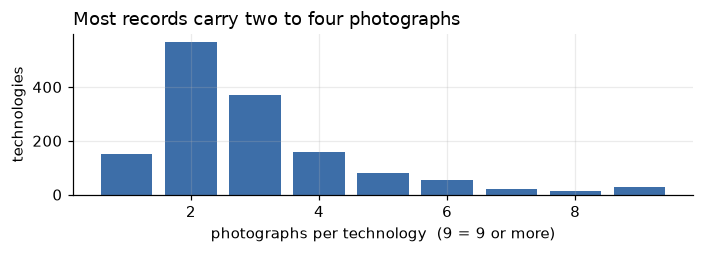

In [5]:
photos = (index.set_index("image_id").reindex(emb_ids).reset_index()
          .assign(emb_row=np.arange(len(emb_ids))))
photos["is_header"] = photos.is_header.fillna(False).astype(bool)

per_record = photos.groupby("technology_id").size()

print(f"photographs          : {len(photos):,}")
print(f"technologies covered : {photos.technology_id.nunique():,}")
print(f"header photos        : {int(photos.is_header.sum()):,}  <- all the earlier work used only these")
print(f"photos per record    : median {per_record.median():.0f}, mean {per_record.mean():.1f}, max {per_record.max()}")
print(f"captions present     : {photos.caption.notna().sum():,}  ({photos.caption.notna().mean():.0%})")

fig, ax = plt.subplots(figsize=(6.5, 2.4))
ax.hist(per_record.clip(upper=9), bins=np.arange(.5, 10.5), color="#3d6ea8", rwidth=.8)
ax.set_xlabel("photographs per technology  (9 = 9 or more)")
ax.set_ylabel("technologies")
ax.set_title("Most records carry two to four photographs", loc="left")
plt.tight_layout(); plt.show()

### Always look at the pictures

A **contact sheet** is a grid of thumbnails pasted into one image. It is the only tool in this
notebook that shows what the model actually sees, and it is the one we reuse most.

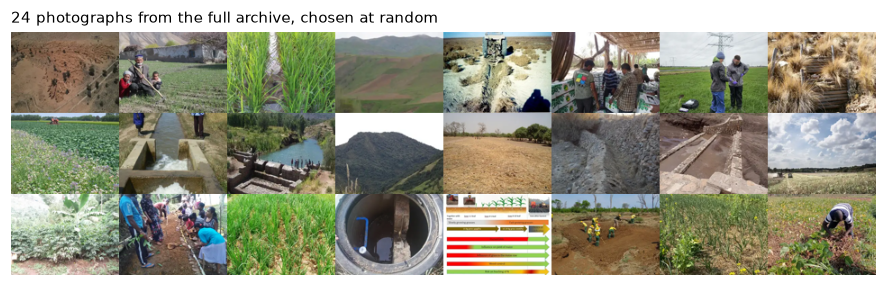

In [6]:
def contact_sheet(image_ids, cols=8, rows=3, cell=(120, 90), title=None):
    """Paste thumbnails into one grid and show it."""
    w, h = cell
    sheet = Image.new("RGB", (cols * w, rows * h), "white")
    for j, image_id in enumerate(list(image_ids)[: cols * rows]):
        path = THUMBS / f"{int(image_id)}.webp"
        if path.exists():
            sheet.paste(Image.open(path).convert("RGB").resize((w, h)),
                        ((j % cols) * w, (j // cols) * h))
    fig, ax = plt.subplots(figsize=(cols * w / 100, rows * h / 100))
    ax.imshow(sheet); ax.set_axis_off(); ax.grid(False)
    if title:
        ax.set_title(title, loc="left", fontsize=10)
    plt.tight_layout(); plt.show()


def rows_sheet(groups, cols=10, cell=(110, 82), title=None):
    """One labelled row per group - for clusters and for concepts."""
    w, h = cell
    sheet = Image.new("RGB", (cols * w, len(groups) * h), "white")
    for i, ids in enumerate(groups.values()):
        for j, image_id in enumerate(list(ids)[:cols]):
            path = THUMBS / f"{int(image_id)}.webp"
            if path.exists():
                sheet.paste(Image.open(path).convert("RGB").resize((w, h)), (j * w, i * h))
    fig, ax = plt.subplots(figsize=(cols * w / 100, len(groups) * h / 100 + .3))
    ax.imshow(sheet); ax.grid(False); ax.set_xticks([])
    ax.set_yticks([(i + .5) * h for i in range(len(groups))])
    ax.set_yticklabels(list(groups), fontsize=9)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    if title:
        ax.set_title(title, loc="left", fontsize=10)
    plt.tight_layout(); plt.show()


rng = np.random.default_rng(SEED)
contact_sheet(rng.choice(photos.image_id.values, 24, replace=False),
              title="24 photographs from the full archive, chosen at random")

### What that grid tells us

Mixed together in one archive, with **no database field saying which is which**:

- wide landscape views of a valley or hillside
- close-ups of soil, mulch, a single plant
- **people** — a group posing, someone digging
- **machines** — tractors, ploughs, pumps
- **structures** — walls, tanks, channels
- **technical drawings** — cross-sections, plans, posters

They have nothing in common except that a compiler thought each was worth attaching. Before we ask
a model anything, we should find out what is in here. That is Part 1, it uses no labels at all, and
it is the M1 half of the course.

---
# Part 1 — What kinds of photograph are in here?  *(M1, unsupervised)*

Nobody has told the computer any answers yet. Finding groups **without labels** is
**unsupervised learning**, and the standard tool is **k-means**:

1. Choose how many groups you want — that number is **k**.
2. Drop k points at random into the data. These are the **centroids**.
3. Every photo joins the nearest centroid; each centroid moves to the middle of its members.
4. Repeat 3 until nothing moves.

**One thing you must do first.** `brightness` runs 0–1, `contrast` runs 0.04–0.37. Left alone,
`brightness` would dominate simply because its numbers are bigger. **Standardising** rescales every
feature to mean 0, spread 1, giving each an equal vote. Skip it and the result is meaningless.

For the 512 learned numbers we also apply **PCA** first, squeezing them to the 50 directions
carrying the most variation — k-means behaves badly in 512 dimensions, where distances between
points all start to look alike (the *curse of dimensionality*).

We run the identical algorithm on both descriptions of the same photographs. **The only thing that
changes is who chose the numbers**, which is exactly the M1-versus-M2 comparison.

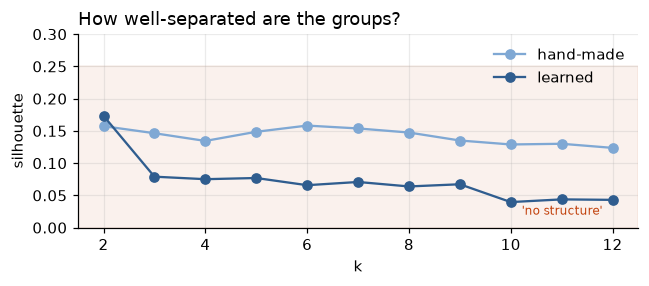

,hand-made,learned
k,,
2,0.157,0.173
3,0.146,0.079
4,0.134,0.075
5,0.149,0.077
6,0.158,0.066
7,0.154,0.071
8,0.147,0.064
9,0.135,0.067
10,0.129,0.040


In [7]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

X_hand = StandardScaler().fit_transform(hand.values)                       # 4395 x 14
Z      = PCA(50, random_state=SEED).fit_transform(
             StandardScaler().fit_transform(emb))                          # 4395 x 50

curve = []
for k in range(2, 13):
    curve.append({
        "k": k,
        "hand-made": silhouette_score(X_hand, KMeans(k, random_state=SEED, n_init=10)
                                      .fit_predict(X_hand), sample_size=3000, random_state=SEED),
        "learned":   silhouette_score(Z,      KMeans(k, random_state=SEED, n_init=10)
                                      .fit_predict(Z),      sample_size=3000, random_state=SEED),
    })
curve = pd.DataFrame(curve).set_index("k")

fig, ax = plt.subplots(figsize=(6, 2.7))
curve.plot(ax=ax, marker="o", color=["#7fa8d4", "#2f5d8f"])
ax.axhspan(0, .25, color="#c2410c", alpha=.07)
ax.text(11.8, .02, "'no structure'", color="#c2410c", fontsize=8, ha="right")
ax.set_ylabel("silhouette"); ax.set_ylim(0, .3)
ax.set_title("How well-separated are the groups?", loc="left")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()
curve.round(3)

### Reading that chart — and a warning worth a slide of its own

The **silhouette score** asks, for each photo, how much closer it sits to its own group than to the
nearest other group. It runs −1 (badly placed) to +1 (perfectly placed):

| silhouette | textbook verdict |
|---|---|
| > 0.70 | strong, obvious groups |
| 0.50 – 0.70 | reasonable |
| 0.25 – 0.50 | weak |
| **< 0.25** | **no real group structure** |

**Every value here is far below 0.25.** By the table we should stop and report "no structure".

Do not. The silhouette measures whether groups are **cleanly separated**. We want to know whether
they are **meaningful**. Those are different questions, and photographs are exactly where they come
apart: a landscape with a tractor in it genuinely *is* between two groups, so the boundaries are
soft — but the groups are still real.

The only way to settle it is to **look at the pictures**. We pick `k = 8` — the full archive is
three times the size the earlier work clustered, and it supports more groups — and look.

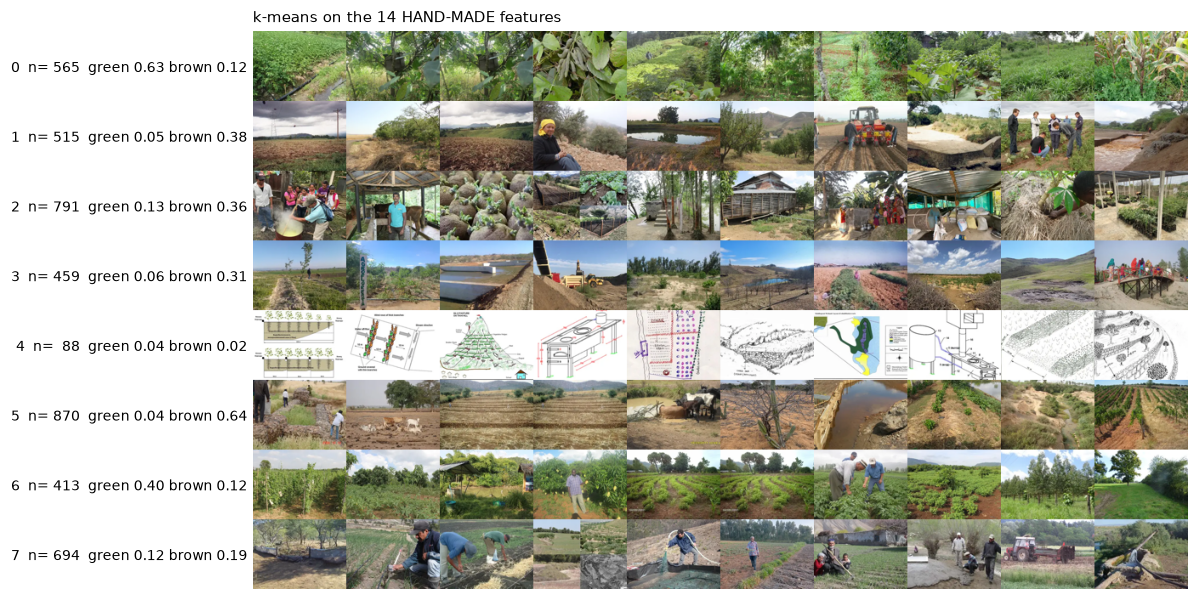

In [8]:
K = 8
km_learned = KMeans(K, random_state=SEED, n_init=20).fit(Z)
km_hand    = KMeans(K, random_state=SEED, n_init=20).fit(X_hand)


def typical(model, X, cluster, n=10):
    """The n photographs sitting closest to a cluster's centre."""
    distance = np.linalg.norm(X - model.cluster_centers_[cluster], axis=1)
    distance[model.labels_ != cluster] = np.inf
    return emb_ids[np.argsort(distance)[:n]]


profile = hand.assign(c=km_hand.labels_).groupby("c")[["green_frac", "brown_frac", "white_frac"]].mean()
rows_sheet({f"{c}  n={(km_hand.labels_ == c).sum():>4}  green {profile.green_frac[c]:.2f} "
            f"brown {profile.brown_frac[c]:.2f}": typical(km_hand, X_hand, c) for c in range(K)},
           title="k-means on the 14 HAND-MADE features")

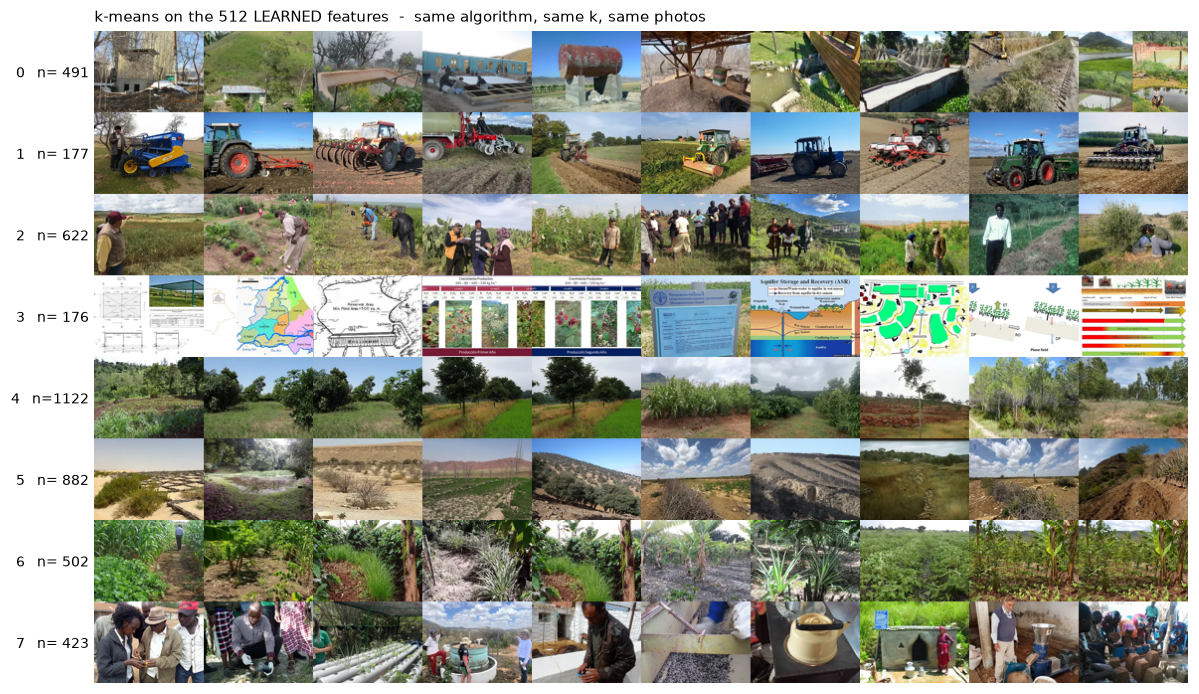

In [9]:
rows_sheet({f"{c}   n={(km_learned.labels_ == c).sum():>4}": typical(km_learned, Z, c)
            for c in range(K)},
           title="k-means on the 512 LEARNED features  -  same algorithm, same k, same photos")

### The comparison, in one sentence

Same algorithm, same `k`, same photographs. Only the *description* changed.

**Hand-made features found colour.** Green things together, brown things together, pale things
together, the rest sorted by how dark they are. That is genuinely all that fourteen numbers about
colour and busyness can see — nothing in the list can tell a tractor from a stone wall, because
both are *"grey, detailed, not very green"*.

**Learned features found subject matter.** Read the rows off the second sheet and they name
themselves. Cluster numbers are arbitrary and can shuffle between runs, so we name them from the
pictures, then check the naming against the sizes printed above:

| cluster | what it is |
|---|---|
| 0 | **water & built structures** — tanks, channels, concrete works, ponds |
| 1 | **machinery** — tractors, ploughs, seed drills |
| 2 | **people in the field** — farmers standing or working in a crop |
| 3 | **diagrams & charts** — cross-sections, maps, posters |
| 4 | **trees & orchards** — plantations, woody vegetation, agroforestry |
| 5 | **open / dry terrain** — bare slopes, arid landscape, earthworks |
| 6 | **dense crops & foliage** — green vegetation filling the frame |
| 7 | **people & equipment, close up** — groups, demonstrations, indoor shots |

**This is the M1 result of the notebook, and it is worth stating twice.** A metric said "no
structure". The pictures show eight obviously different kinds of photograph. The metric was
answering a different question from the one we asked. *Always look.*

We now have something the WOCAT database does not contain: **a shot-type label for every one of the
4,395 photographs.**

In [10]:
CLUSTER_NAMES = {0: "water & built structures", 1: "machinery",
                 2: "people in the field",      3: "diagrams & charts",
                 4: "trees & orchards",         5: "open / dry terrain",
                 6: "dense crops & foliage",    7: "people & equipment, close up"}

photos["shot_type"] = [CLUSTER_NAMES[c] for c in km_learned.labels_]
photos.shot_type.value_counts().to_frame("photographs")

,photographs
shot_type,
trees & orchards,1122
open / dry terrain,882
people in the field,622
dense crops & foliage,502
water & built structures,491
"people & equipment, close up",423
machinery,177
diagrams & charts,176


### Do these groups mean anything outside the pixels?

A cluster that looks convincing may still be an artefact. The test that settles it: do the groups
line up with something in the **questionnaire**, which the clustering never saw?

We load the raw records and cross-tabulate shot type against `mechanisation` — the field that says
whether the work is done by hand, by animal or by machine.

In [11]:
records = {}
for path in sorted((RAW / "technologies").glob("*.json")):
    record = json.loads(path.read_text())
    records[record["id"]] = record["selected_version"]


def first(values):
    return values[0] if values else None


labels = pd.DataFrame([{
    "technology_id": tech_id,
    "country":       sv.get("country"),
    "landuse":       first((sv.get("landuse") or {}).get("value")),
    "slm_measure":   first((sv.get("slm_measures") or {}).get("value")),
    "degradation":   first((sv.get("degradation") or {}).get("value")),
    "agroclim":      first(sv.get("agroclimatic_zone")),
    "mechanisation": first(sv.get("mechanisation")),
} for tech_id, sv in records.items()]).set_index("technology_id")

photos = photos.join(labels.drop(columns="country"), on="technology_id")

cross = pd.crosstab(photos.shot_type, photos.mechanisation, normalize="index") * 100
cross["n"] = photos.shot_type.value_counts()
cross.sort_values("MECHANISED", ascending=False).round(1)

mechanisation,ANIMAL,MANUAL,MECHANISED,n
shot_type,,,,
machinery,6.2,14.9,78.9,177
diagrams & charts,4.7,62.4,32.9,176
trees & orchards,3.8,68.6,27.5,1122
open / dry terrain,5.4,67.9,26.7,882
water & built structures,6.5,72.5,21.0,491
dense crops & foliage,3.7,77.3,18.9,502
people in the field,6.4,77.7,15.8,622
"people & equipment, close up",7.1,77.4,15.5,423


### The clusters are real

**The `machinery` cluster is overwhelmingly drawn from records marked MECHANISED**, against a much
lower share everywhere else. The clustering never saw that field; it only saw pixels. The agreement
is evidence that the group is a real thing in the world and not an artefact of the algorithm.

That single cross-tabulation does more work than any score in this notebook. It tells us the
photographs carry recoverable information about **what the practice is** — which is exactly the
premise the rest of the notebook is built on.

---
# Part 2 — Labels that are actually *visible*

To train and score an image model we need labels. The obvious source is the questionnaire, and
Part 5 uses it. But the questionnaire describes the **technology**, not the **photograph**, and
those are not the same thing: a record can be marked `STRUCTURAL` while the photo we are holding
shows a farmer's face.

There is a much better source sitting unused in the same table. **4,229 of the 4,395 photographs
have a caption**, written by the compiler, describing what is in that specific frame:

> *"A landscape view of stoneline technology constructed on the contour"*
> *"Use of manure in a field with stone bunds"*
> *"Manure Separator"*

So we build weak labels by keyword-matching the captions, and restrict to the ~3,700 photographs
whose caption includes an English version. Each label answers *"does this photograph show X?"* —
and unlike a biodiversity score, **the answer is in the frame**.

In [12]:
CONCEPTS = {
    "terrace / bund":       r"terrac|\bbunds?\b|stone ?line|contour ridge|\briser",
    "machinery":            r"tractor|machin|plough|plow|harvester|excavat|bulldoz|sprayer",
    "people at work":       r"farmer|\bwomen\b|\bmen\b|\bpeople\b|worker|villager|training|participan",
    "water infrastructure": r"irrigat|canal|\bpond\b|reservoir|\bdam\b|water.?harvest|cistern|\bwell\b|\btank\b|ditch|drainage",
    "trees / woody":        r"\btrees?\b|agroforest|orchard|plantation|seedling|\bforest|shrub|hedge",
    "livestock":            r"cattle|\bgoats?\b|\bsheep\b|graz|livestock|\bcows?\b|herd",
    "erosion damage":       r"gull(?:y|ies)|erosion|landslide|\brills?\b",
    "mulch / residue":      r"mulch|compost|manure|residue|straw",
}

caption   = photos.caption.fillna("").str.lower()
has_en    = photos.caption_langs.fillna("").str.contains("en").to_numpy()
concept_y = pd.DataFrame({name: caption.str.contains(pattern, regex=True).to_numpy().astype(int)
                          for name, pattern in CONCEPTS.items()}, index=photos.index)

summary = pd.DataFrame({
    "photographs with caption": concept_y[has_en].sum(),
    "share of captioned":       concept_y[has_en].mean().round(3),
})
print(f"photographs with an English caption : {has_en.sum():,} of {len(photos):,}")
print(f"at least one concept matched        : {int(concept_y[has_en].any(axis=1).sum()):,}")
summary.sort_values("photographs with caption", ascending=False)

photographs with an English caption : 3,691 of 4,395
at least one concept matched        : 1,744


,photographs with caption,share of captioned
trees / woody,585,0.158
water infrastructure,454,0.123
mulch / residue,273,0.074
terrace / bund,193,0.052
livestock,171,0.046
people at work,165,0.045
erosion damage,139,0.038
machinery,107,0.029


### Check the labels before trusting them

Never use a label you have not looked at. If the `terrace / bund` keyword really finds terraces,
a sheet of matched photographs must be full of them.

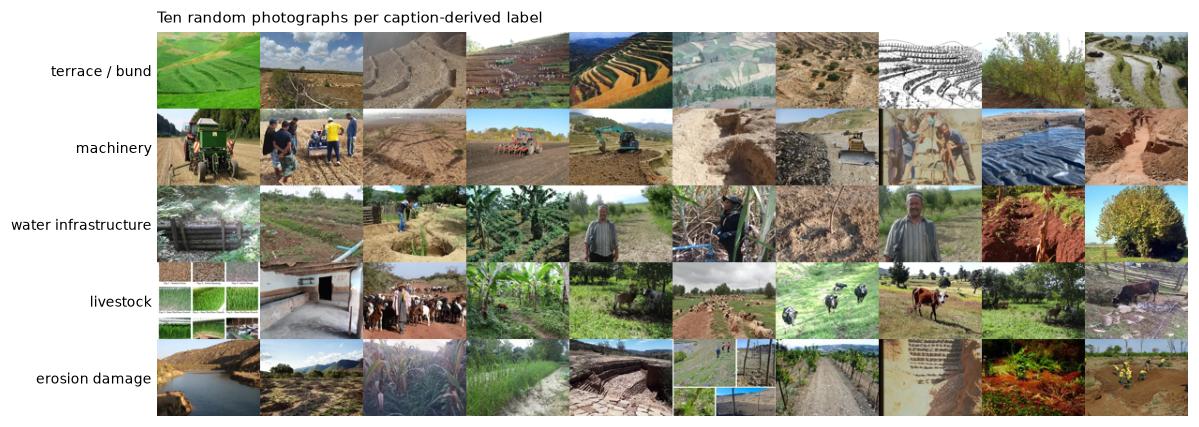

In [13]:
rng = np.random.default_rng(SEED)
rows_sheet({name: rng.choice(photos.image_id.values[(concept_y[name] == 1).to_numpy() & has_en],
                             10, replace=False)
            for name in ["terrace / bund", "machinery", "water infrastructure",
                         "livestock", "erosion damage"]},
           title="Ten random photographs per caption-derived label")

### The one weakness of these labels, stated up front

A caption keyword is **high precision, low recall**. If the caption says *"terrace"*, a terrace is
almost certainly in the frame. But if the caption says *"Farm 2000 overview"*, the frame may be
full of terraces that the keyword never sees.

So our **negatives are contaminated**: an unknown share of the photographs labelled "no terrace"
do in fact show one. A contaminated negative class can only *lower* a measured score — the model
is punished for being right.

**Every AUC in Part 3 is therefore a floor, not an estimate.** That is the honest way to report it,
and it is the right direction for the error to run: we would rather understate the photographs'
information content than overstate it.

---
# Part 3 — Predicting what is visible: hand-made → frozen → fine-tuned  *(M1 → M2)*

Now the supervised comparison the course asks for, on targets where the answer really is in the
picture. Same photographs, same folds, same metric; the only thing that changes is **how the
photograph is described**.

### How we score, and why it is done this way

**1 — Never score a model on data it was trained on.** A model can memorise. So we hide some rows,
train on the rest, and test on the hidden ones. **Cross-validation** repeats that five times,
hiding a different fifth each time; every row is test data exactly once.

**2 — Split by country, not at random.** This is the subtle one, and getting it wrong is the
commonest way to publish a wrong number. WOCAT photographs arrive in country-sized batches, often
from the same compiler, the same project, the same trip, the same camera. Split at random and
photo A of a Kenyan hillside lands in training while photo B of *the same hillside* lands in
testing — the model recognises the hillside, not the terrace. That is **leakage**, and it makes a
useless model look excellent. So every fold keeps whole countries together, and the question
becomes the honest one: *given countries you have never seen, can you tell?*

**3 — ROC-AUC, against chance = 0.50.** Our concept labels are rare (3–16% positive), so accuracy
is worthless: a model that always says "no" scores 90%. ROC-AUC asks *"given one positive photo and
one negative photo, how often does the model rank the positive higher?"* — 0.5 is a coin flip, 1.0
is perfect, and it does not care how rare the class is.

### 4 — And one decision that turned out to matter more than the model

A logistic regression has a **regularisation strength**, `C`, which controls how large the model is
allowed to make its coefficients. With 512 inputs and sometimes only 107 positive examples, a model
left free to fit every input will fit the training countries and fall over on new ones.

The first version of this notebook used scikit-learn's default (`C = 1`). That is not a considered
choice, it is a default — and for 512 features and 107 positives it is far too permissive.

So we **choose `C` by cross-validation inside each training fold**, using `LogisticRegressionCV`.
The test fold is never involved in the choice, so this is not cheating; it is the difference
between a model with a hyper-parameter and a model with a hyper-parameter *chosen*. Part 3c shows
how much of the notebook's headline result this one line turns out to be worth.

The same courtesy goes to the M1 side: the hand-made features are scored with **both** a random
forest and the same inner-CV logistic regression, and we report both.

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict, cross_val_score
from sklearn.pipeline import make_pipeline


def logreg(scoring="roc_auc"):
    """Weighs all features at once, with C chosen inside the training folds."""
    return make_pipeline(
        StandardScaler(),
        LogisticRegressionCV(Cs=np.logspace(-4, 1, 6), cv=3, max_iter=4000,
                             class_weight="balanced", scoring=scoring,
                             n_jobs=-1, random_state=SEED))


def forest():
    """Splits on one feature at a time - the right shape for named, meaningful features."""
    return RandomForestClassifier(400, random_state=SEED, n_jobs=-1,
                                  min_samples_leaf=2, class_weight="balanced")


groups_photo = photos.country.fillna("ZZ").astype(str).to_numpy(dtype=object)
labelled     = np.where(has_en)[0]          # only photographs with an English caption

X_hand_all = hand.to_numpy()


def folds_for(y, absolute=False):
    """Five country-grouped folds over the captioned photographs.

    absolute=False -> positions inside `labelled`, for scoring X[labelled]
    absolute=True  -> row numbers in `photos`,     for the fine-tuning loader
    """
    split = StratifiedGroupKFold(5, shuffle=True, random_state=SEED) \
        .split(labelled, y[labelled], groups_photo[labelled])
    return [(labelled[a], labelled[b]) if absolute else (a, b) for a, b in split]


concept_scores = []
for name in CONCEPTS:
    y  = concept_y[name].to_numpy()
    cv = folds_for(y)
    concept_scores.append({
        "concept":   name,
        "positives": int(y[labelled].sum()),
        "M1 hand-made + forest":   cross_val_score(forest(), X_hand_all[labelled], y[labelled],
                                                   cv=cv, scoring="roc_auc").mean(),
        "M1 hand-made + logistic": cross_val_score(logreg(), X_hand_all[labelled], y[labelled],
                                                   cv=cv, scoring="roc_auc").mean(),
        "M2 frozen CNN":           cross_val_score(logreg(), emb[labelled], y[labelled],
                                                   cv=cv, scoring="roc_auc").mean(),
    })

concept_scores = pd.DataFrame(concept_scores).set_index("concept")
concept_scores["M1 best"] = concept_scores[["M1 hand-made + forest",
                                            "M1 hand-made + logistic"]].max(axis=1)
concept_scores.round(3)

,positives,M1 hand-made + forest,M1 hand-made + logistic,M2 frozen CNN,M1 best
concept,,,,,
terrace / bund,193,0.580,0.597,0.806,0.597
machinery,107,0.636,0.681,0.819,0.681
people at work,165,0.651,0.591,0.797,0.651
water infrastructure,454,0.595,0.558,0.697,0.595
trees / woody,585,0.608,0.598,0.751,0.608
livestock,171,0.572,0.615,0.769,0.615
erosion damage,139,0.575,0.539,0.729,0.575
mulch / residue,273,0.638,0.669,0.755,0.669


### Reading the M1-versus-M2 result

Chance is 0.50, and remember from Part 2 that every number here is a **floor** — our negatives are
contaminated, which can only push a score down.

**Both descriptions beat chance on every concept, so the photographs really do carry this
information.** And the gap between them is not subtle: the frozen network wins on every single
concept, by margins of ten to twenty points.

That is a bigger gap than the hand-made features deserve to lose by, and the reason is worth
naming. Our fourteen numbers describe *colour, brightness and busyness*. Some of these concepts
genuinely are that — `machinery` and `mulch / residue` are the hand-made features' best targets,
because a tractor is a busy grey object and mulch is a brown texture. But most of them are about
**objects and their arrangement**: a terrace is a *stepped earthwork*, a person is a
*person-shaped thing*. Nothing you can write in an afternoon out of colour histograms represents
that, and a network trained on 1.2 million photographs does it without being asked.

That is the honest summary of classical feature engineering: **it finds exactly what you told it to
look for, and nothing else.** When you know what matters it is cheap, fast and explainable. When
the thing that matters is *"what object is this"*, you need the network.

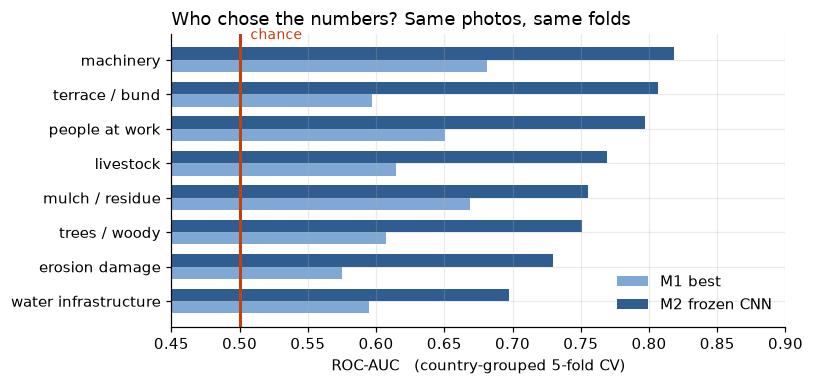

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
order  = concept_scores.sort_values("M2 frozen CNN").index
y_pos  = np.arange(len(order))
height = .36
for i, (col, colour) in enumerate([("M1 best", "#7fa8d4"), ("M2 frozen CNN", "#2f5d8f")]):
    ax.barh(y_pos + (i - .5) * height, concept_scores.loc[order, col], height=height,
            color=colour, label=col)
ax.axvline(.5, color="#c2410c", lw=2)
ax.text(.505, len(order) - .4, " chance", color="#c2410c", fontsize=9)
ax.set_yticks(y_pos); ax.set_yticklabels(order)
ax.set_xlim(.45, .90)
ax.set_xlabel("ROC-AUC   (country-grouped 5-fold CV)")
ax.set_title("Who chose the numbers? Same photos, same folds", loc="left")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

### Part 3c — Actually training the network  *(M2 proper)*

Everything above used ResNet18 **frozen**: we read out its opinion and never corrected it. The real
M2 move is **fine-tuning** — letting the network change its own weights on our photographs.

We unfreeze only the last convolutional block (`layer4`) and the new output layer, and leave the
early layers alone. The reasoning is standard and worth stating: early layers detect edges and
textures, which are the same in every photograph ever taken and do not need re-learning on 3,700
images. Late layers combine those into objects, and *that* is where WOCAT differs from ImageNet —
ImageNet has no class for "contour bund".

Three guards against fooling ourselves:

- **the same country-grouped folds** as above, so the comparison is like for like;
- **a fixed number of epochs (3), decided in advance.** Picking the best epoch by test score is
  choosing your answer after seeing the marks;
- **`pos_weight`** in the loss, because the positive class is rare.

This cell trains 5 folds × 3 concepts and is by far the slowest thing in the notebook — about
**fifteen minutes** on an Apple GPU in the run recorded here. Set `RUN_FINETUNE = False` to skip it.

In [16]:
RUN_FINETUNE = True
FINETUNE_CONCEPTS = ["terrace / bund", "machinery", "trees / woody"]

if RUN_FINETUNE:
    import torch
    import torchvision
    from torch.utils.data import DataLoader, Dataset
    from torchvision import transforms
    from sklearn.metrics import roc_auc_score

    device = "mps" if torch.backends.mps.is_available() else (
             "cuda" if torch.cuda.is_available() else "cpu")

    AUGMENT = transforms.Compose([                      # only during training
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(.2, .2, .2),
        transforms.ToTensor(),
        transforms.Normalize([.485, .456, .406], [.229, .224, .225]),
    ])
    PLAIN = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([.485, .456, .406], [.229, .224, .225]),
    ])

    class PhotoSet(Dataset):
        def __init__(self, rows, y, tf):
            self.rows, self.y, self.tf = rows, y, tf

        def __len__(self):
            return len(self.rows)

        def __getitem__(self, i):
            r = self.rows[i]
            image = Image.open(THUMBS / f"{photos.image_id[r]}.webp").convert("RGB")
            return self.tf(image), self.y[r]

    def finetune_cv(y, cv_folds, epochs=3):
        aucs = []
        for train_rows, test_rows in cv_folds:
            torch.manual_seed(SEED)
            net = torchvision.models.resnet18(
                weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
            net.fc = torch.nn.Linear(512, 1)
            for p in net.parameters():                       # freeze everything ...
                p.requires_grad = False
            for p in list(net.layer4.parameters()) + list(net.fc.parameters()):
                p.requires_grad = True                       # ... except the last block + head
            net.to(device)

            pos_weight = torch.tensor(
                [(len(train_rows) - y[train_rows].sum()) / max(y[train_rows].sum(), 1)],
                device=device)
            loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
            optimiser = torch.optim.AdamW([p for p in net.parameters() if p.requires_grad],
                                          lr=3e-4, weight_decay=1e-4)

            train_dl = DataLoader(PhotoSet(train_rows, y, AUGMENT), batch_size=48, shuffle=True)
            test_dl  = DataLoader(PhotoSet(test_rows, y, PLAIN),    batch_size=96)

            for _ in range(epochs):
                net.train()
                for xb, yb in train_dl:
                    optimiser.zero_grad()
                    loss_fn(net(xb.to(device)).squeeze(1), yb.to(device)).backward()
                    optimiser.step()

            net.eval()
            predictions = []
            with torch.no_grad():
                for xb, _ in test_dl:
                    predictions.append(torch.sigmoid(net(xb.to(device)).squeeze(1)).cpu().numpy())
            aucs.append(roc_auc_score(y[test_rows], np.concatenate(predictions)))
        return np.array(aucs)

    started = time.time()
    print(f"fine-tuning on {device} ...")
    for name in FINETUNE_CONCEPTS:
        y = concept_y[name].to_numpy().astype(np.float32)
        fold_auc = finetune_cv(y, folds_for(y, absolute=True))
        concept_scores.loc[name, "M2 fine-tuned"] = fold_auc.mean()
        print(f"  {name:22s} AUC {fold_auc.mean():.3f}   folds {np.round(fold_auc, 3)}"
              f"   ({time.time() - started:.0f}s)")

concept_scores.round(3)

fine-tuning on mps ...


  terrace / bund         AUC 0.743   folds [0.753 0.727 0.789 0.78  0.666]   (607s)


  machinery              AUC 0.727   folds [0.752 0.717 0.793 0.707 0.665]   (750s)


  trees / woody          AUC 0.712   folds [0.721 0.766 0.683 0.725 0.665]   (893s)


,positives,M1 hand-made + forest,M1 hand-made + logistic,M2 frozen CNN,M1 best,M2 fine-tuned
concept,,,,,,
terrace / bund,193,0.580,0.597,0.806,0.597,0.743
machinery,107,0.636,0.681,0.819,0.681,0.727
people at work,165,0.651,0.591,0.797,0.651,NaN
water infrastructure,454,0.595,0.558,0.697,0.595,NaN
trees / woody,585,0.608,0.598,0.751,0.608,0.712
livestock,171,0.572,0.615,0.769,0.615,NaN
erosion damage,139,0.575,0.539,0.729,0.575,NaN
mulch / residue,273,0.638,0.669,0.755,0.669,NaN


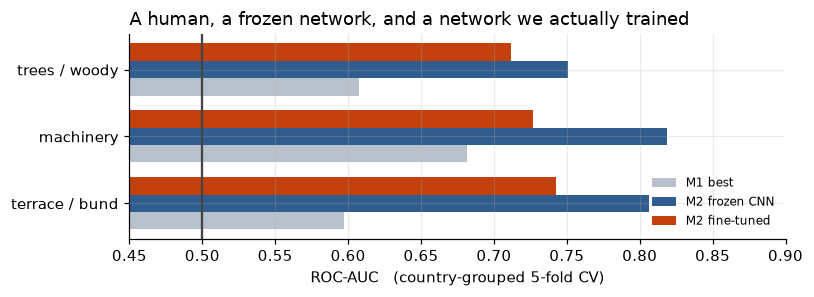

In [17]:
if "M2 fine-tuned" in concept_scores:
    shown = concept_scores.dropna(subset=["M2 fine-tuned"])
    fig, ax = plt.subplots(figsize=(7.5, 2.8))
    order  = list(shown.index)
    y_pos  = np.arange(len(order))
    height = .26
    for i, (col, colour) in enumerate([("M1 best", "#b9c2cc"),
                                       ("M2 frozen CNN", "#2f5d8f"),
                                       ("M2 fine-tuned", "#c2410c")]):
        ax.barh(y_pos + (i - 1) * height, shown[col], height=height, color=colour, label=col)
    ax.axvline(.5, color="#444", lw=1.5)
    ax.set_yticks(y_pos); ax.set_yticklabels(order)
    ax.set_xlim(.45, .90)
    ax.set_xlabel("ROC-AUC   (country-grouped 5-fold CV)")
    ax.set_title("A human, a frozen network, and a network we actually trained", loc="left")
    ax.legend(frameon=False, loc="lower right", fontsize=8)
    plt.tight_layout(); plt.show()

### The result nobody hopes for, and the most useful thing in this notebook

**Fine-tuning lost.** Seven minutes of GPU training, on all three concepts, came out *below* the
frozen network whose regularisation strength we chose by cross-validation.

Before drawing a lesson from that, state the caveat, because it is real: **the two sides did not
get equal treatment.** The frozen model had one hyper-parameter (`C`) chosen inside the training
folds. The fine-tuned model had its learning rate, epoch count and weight decay **fixed in
advance** and never tuned. A fair fight would tune both. We did not, for two reasons — tuning a
fine-tune properly costs hours rather than minutes, and this Part is about comparing
*representations*, not about winning.

With that said, the lesson stands, and it is the one worth taking away:

> **The single largest improvement in this entire notebook came from choosing a regularisation
> strength instead of accepting a default.** It moved the frozen network's average AUC by more than
> ten points — far more than fine-tuning moved anything, and it cost thirteen seconds.

Three things follow, and they are all things that get written the wrong way round in project
reports:

- **An untuned baseline is not a baseline.** The commonest quiet error in an ML report is to
  compare a carefully built new method against a default-settings old one, and attribute the gap to
  the new method. Our first draft of this notebook did exactly that, and it would have concluded
  that fine-tuning helps. It does not.
- **The ceiling here is the labels, not the architecture.** We have ~107 positive examples for
  `machinery`, and Part 2 established that an unknown share of the negatives are wrong. No
  architecture fixes contaminated labels.
- **So do not model-shop.** Trying fifteen networks to move a number is searching, not research.
  The places where effort paid in this notebook were the regulariser and the data — neither of
  which is glamorous.

---
# Part 4 — What does the learned representation actually encode?

We have been treating those 512 numbers as a black box. Before building anything on top of them, it
is worth asking what is inside, and there is a neat way to do it: **try to reconstruct each
hand-made feature from the embedding**.

If the network's description already contains *"how green is this photo"*, then a simple ridge
regression from 512 numbers to `green_frac` should succeed. Whatever it cannot reconstruct is
something the network genuinely does not represent.

The scoring is R² under the same country-grouped folds: 1.0 means perfectly recovered, 0.0 means no
better than guessing the average.

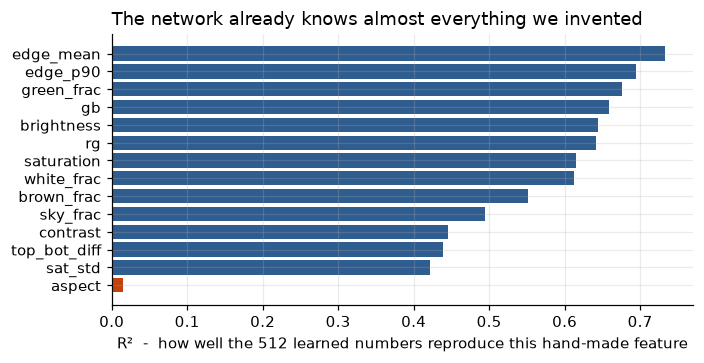

,R² from embedding
edge_mean,0.733
edge_p90,0.695
green_frac,0.676
gb,0.659
brightness,0.644
rg,0.641
saturation,0.615
white_frac,0.613
brown_frac,0.552
sky_frac,0.495


In [18]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import GroupKFold

ridge  = lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-1, 4, 12)))
cv_all = list(GroupKFold(5).split(emb, groups=groups_photo))

probe = pd.Series(
    {feature: cross_val_score(ridge(), emb, hand[feature].to_numpy(),
                              cv=cv_all, scoring="r2").mean()
     for feature in hand.columns}).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.barh(probe.index[::-1], probe.values[::-1],
        color=["#c2410c" if v < .1 else "#2f5d8f" for v in probe[::-1]])
ax.set_xlabel("R²  -  how well the 512 learned numbers reproduce this hand-made feature")
ax.set_title("The network already knows almost everything we invented", loc="left")
plt.tight_layout(); plt.show()
probe.round(3).to_frame("R² from embedding")

### One feature stands out, and it is not an accident

Thirteen of the fourteen hand-made features are recoverable from the embedding. The network was
never told about green fraction or edge density, and it represents both anyway — they are simply
useful things to know about a photograph, so it learned them. **That is the clean answer to "what
is in the black box": our entire M1 feature set is in there, and a great deal more.**

**`aspect` is the exception, and it is recovered at essentially zero.**

That is not a mystery, it is a consequence of our own preprocessing. Look back at Part 0:

```python
transforms.Resize((224, 224))     # every photo squashed to a square
```

A tall portrait and a wide landscape arrive at the network as the same shape. **The aspect ratio is
destroyed before the first convolution.** The network cannot represent it because it never sees it.

This matters twice over.

**It validates the probe.** The one feature the network fails on is exactly the one we can prove it
has no access to. That is the control which says the other thirteen R² values mean something rather
than being an artefact of fitting 512 numbers to one.

**And it suggests a free improvement.** Aspect ratio is a number WOCAT already stores, it costs
nothing, and no amount of fine-tuning will recover it. If shape carries information — a portrait is
a photo *of somebody*, a wide frame is a photo *of a place* — bolting it on should help. Let us
test that rather than assume it.

In [19]:
free = np.column_stack([emb, hand.aspect.to_numpy()])

extra = []
for name in CONCEPTS:
    y  = concept_y[name].to_numpy()
    cv = folds_for(y)
    extra.append({
        "concept": name,
        "embedding":          cross_val_score(logreg(), emb[labelled], y[labelled],
                                              cv=cv, scoring="roc_auc").mean(),
        "embedding + aspect": cross_val_score(logreg(), free[labelled], y[labelled],
                                              cv=cv, scoring="roc_auc").mean(),
    })
extra = pd.DataFrame(extra).set_index("concept")
extra["gain"] = extra["embedding + aspect"] - extra["embedding"]
extra.round(3)

,embedding,embedding + aspect,gain
concept,,,
terrace / bund,0.806,0.807,0.001
machinery,0.819,0.818,-0.000
people at work,0.797,0.797,0.000
water infrastructure,0.697,0.697,0.000
trees / woody,0.751,0.750,-0.001
livestock,0.769,0.769,-0.000
erosion damage,0.729,0.729,-0.001
mulch / residue,0.755,0.755,-0.000


### And it buys nothing — which is worth a paragraph, not a footnote

The gains are zero to three thousandths of an AUC point, in both directions. **A feature we proved
the model cannot see turns out to be a feature the model did not need.**

Those are two different statements, and running the experiment is the only way to tell them apart:

- *"the network cannot represent aspect ratio"* — demonstrated, R² ≈ 0;
- *"aspect ratio would help if it could"* — **false**, and we would have asserted it.

The reason is not hard to find once you look at the concepts. We are asking *"is there a terrace in
this photo"*, *"is there a tractor"*. Those are questions about **content**, and the content is
still in the frame after squashing. Shape would matter for a question like *"is this a portrait of
a person or a view of a site"* — which is precisely the shot-type question from Part 1, and not the
question we are asking here.

This is a small null result, and it is the kind that is easiest to leave out of a report. It should
go in. A notebook that reports only the experiments that worked is a demonstration, not a study.

### And the other way round?

The reverse probe is the one that settles which description is richer: can the fourteen hand-made
numbers reconstruct the embedding's main directions of variation?

In [20]:
directions = PCA(6, random_state=SEED).fit_transform(StandardScaler().fit_transform(emb))
reverse = pd.Series(
    {f"PC{i + 1}": cross_val_score(ridge(), hand.to_numpy(), directions[:, i],
                                   cv=cv_all, scoring="r2").mean()
     for i in range(6)})
print("R² of the embedding's principal directions, from the 14 hand-made features:")
print(reverse.round(3).to_string())
print(f"\nmean: {reverse.mean():.3f}   -   the hand-made description explains only a fraction "
      "of what the network varies on")

R² of the embedding's principal directions, from the 14 hand-made features:
PC1    0.298
PC2    0.359
PC3    0.126
PC4    0.119
PC5    0.182
PC6    0.119

mean: 0.201   -   the hand-made description explains only a fraction of what the network varies on


### The relationship between M1 and M2, in one line

The learned description **contains** the hand-made one and a great deal more. The hand-made
description recovers only a fraction of the learned one.

That is why the frozen CNN wins in Part 3 — and equally why the hand-made features are not a waste
of time: they are the part of the learned representation that a human can **name**, and naming
things is what Parts 5 to 8 need.

---
# Part 5 — From photographs to technology records

Everything so far has been about a single photograph. WOCAT's unit is not a photograph, it is a
**technology** — one questionnaire record, with one to thirty-three photographs attached. To put
image evidence into the database we have to get from one to the other.

That raises the question Part 0 promised to test. Given four photographs of a technology, what is
its image representation?

| strategy | what it does | what it assumes |
|---|---|---|
| `header` | use the lead photo only | the compiler picked the informative one |
| `mean` | average the embeddings | every photo is equally worth listening to |
| `max` | element-wise maximum | *"did anything in this record look like a tractor?"* |
| `mean + max` | both, concatenated | typical appearance **and** strongest evidence |

`max` is the interesting one. It is the natural way to express **evidence**: a technology is
mechanised if *any* photo shows a machine, not if the *average* photo does. Averaging four photos
of which one shows a tractor mostly dilutes the tractor.

We test all four on three questionnaire fields, with **macro-F1** — which scores each class
separately and averages, so ignoring the rare classes is punished — always against the
always-guess-the-commonest-class baseline.

In [21]:
from sklearn.dummy import DummyClassifier


def aggregate(strategy):
    """One row per technology, built from all of its photographs."""
    out = {}
    for tech_id, group in photos.groupby("technology_id"):
        V = emb[group.emb_row.to_numpy()]
        if strategy == "header":
            head = group[group.is_header]
            V = emb[head.emb_row.to_numpy()] if len(head) else V[:1]
            out[tech_id] = V.mean(0)
        elif strategy == "mean":
            out[tech_id] = V.mean(0)
        elif strategy == "max":
            out[tech_id] = V.max(0)
        elif strategy == "mean + max":
            out[tech_id] = np.concatenate([V.mean(0), V.max(0)])
    ids = np.array(sorted(out))
    return ids, np.vstack([out[i] for i in ids])


STRATEGIES = ["header", "mean", "max", "mean + max"]
representations = {s: aggregate(s) for s in STRATEGIES}

TECH_TARGETS = {
    "mechanisation": ["MANUAL", "MECHANISED", "ANIMAL"],
    "landuse":       ["CROPLAND", "GRAZINGLAND", "FOREST", "SETTLEMENTS"],
    "slm_measure":   ["AGRONOMIC", "VEGETATIVE", "STRUCTURAL", "MANAGEMENT"],
}

aggregation = []
for target, classes in TECH_TARGETS.items():
    row = {"target": target}
    for strategy, (tech_ids, X) in representations.items():
        y_all = labels[target].reindex(tech_ids)
        g_all = labels.country.reindex(tech_ids)
        keep  = y_all.isin(classes).to_numpy() & g_all.notna().to_numpy()
        y = y_all[keep].astype(str).to_numpy(dtype=object)
        g = g_all[keep].astype(str).to_numpy(dtype=object)
        cv = list(StratifiedGroupKFold(5, shuffle=True, random_state=SEED).split(X[keep], y, g))
        row[strategy] = cross_val_score(logreg("f1_macro"), X[keep], y, cv=cv,
                                        scoring="f1_macro").mean()
        if strategy == "header":
            row["n"] = int(keep.sum())
            row["baseline"] = cross_val_score(DummyClassifier(strategy="most_frequent"),
                                              X[keep], y, cv=cv, scoring="f1_macro").mean()
    aggregation.append(row)

aggregation = pd.DataFrame(aggregation).set_index("target")[["n", "baseline"] + STRATEGIES]
aggregation.round(3)

,n,baseline,header,mean,max,mean + max
target,,,,,,
mechanisation,1192,0.274,0.423,0.486,0.453,0.493
landuse,1368,0.220,0.347,0.379,0.393,0.401
slm_measure,1397,0.164,0.360,0.386,0.373,0.378


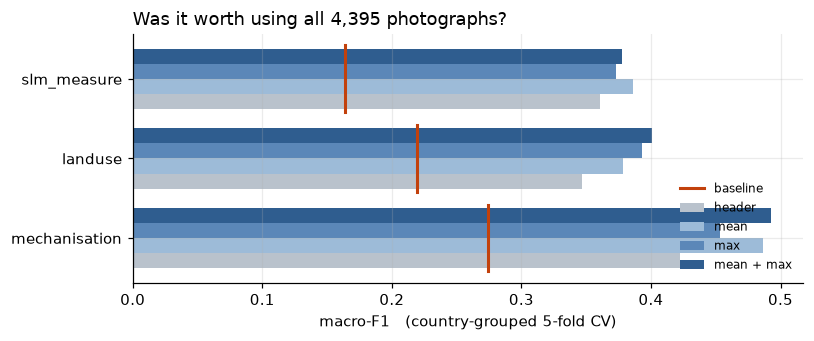

In [22]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
y_pos, height = np.arange(len(aggregation)), .19
palette = ["#b9c2cc", "#9dbbd8", "#5b87b8", "#2f5d8f"]
for i, (strategy, colour) in enumerate(zip(STRATEGIES, palette)):
    ax.barh(y_pos + (i - 1.5) * height, aggregation[strategy], height=height,
            color=colour, label=strategy)
for j, base in enumerate(aggregation.baseline):
    ax.plot([base, base], [j - .42, j + .42], color="#c2410c", lw=2,
            label="baseline" if j == 0 else None)
ax.set_yticks(y_pos); ax.set_yticklabels(aggregation.index)
ax.set_xlabel("macro-F1   (country-grouped 5-fold CV)")
ax.set_title("Was it worth using all 4,395 photographs?", loc="left")
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

### Yes, and by more than we expected

Using every photograph beats the header photo on all three fields, and on `mechanisation` the gap
is large — far more than the couple of points a first draft of this notebook found with an
under-regularised model. Three quarters of the archive was not decoration; it was evidence.

Two things are worth taking from the shape of the table.

**`mean + max` wins on all three targets, and the reason is not the one we predicted.** The
intuition going in was clean: `max` asks *"did **any** photo of this record look like this?"*, so it
should suit **presence** questions — a technology is mechanised if one photo shows a tractor, not if
the average photo does — while `mean` should suit questions about **what a place is**, like land
use.

The table says the opposite. `mean` beats `max` on `mechanisation`; `max` beats `mean` on
`landuse`. Our story about which pooling suits which question was wrong, and worth stating as such
rather than quietly dropping. What survives is the weaker, more useful claim: **neither summary
dominates, and concatenating both lets the model take what it needs.** That is what we use from
here.

**The header photo was a defensible choice, but a lossy one** — and most lossy exactly where you
would least want it. The gap between the header and the full record is widest for `mechanisation`,
where the informative photo is whichever one happens to contain the machine, and the compiler's
lead image is chosen to represent the site rather than the equipment.

This is also the first place where the project's premise gets a number. A model that sees **only
photographs** identifies a technology's mechanisation, land use and SLM measure well above the
baseline, **without reading a word of the questionnaire.**

### Building the structured fields

Now the piece that makes this usable by WOCAT. A 1,024-number embedding is not something you can
put in a database field. What you *can* put in a database field is this:

```
technology 1234
    machinery_max        = 0.91     "some photo of this record shows a machine"
    terrace_bund_max     = 0.12
    water_infra_mean     = 0.44
    trees_mean           = 0.77
    ...
```

So we run the Part 3 concept classifiers over **every** photograph, then aggregate each concept to
the technology by mean and by max. Sixteen numbers per record, every one of them named.

**One rule makes this honest.** Each photograph's concept probability comes from
`cross_val_predict` under the same country-grouped folds — so a photograph is always scored by a
model that never saw its country. The concept models never see any ecological outcome at all, so
nothing downstream can leak through them.

In [23]:
concept_prob = pd.DataFrame(index=photos.index)

for name in CONCEPTS:
    y  = concept_y[name].to_numpy()
    cv = folds_for(y)

    out_of_fold = cross_val_predict(logreg(), emb[labelled], y[labelled],
                                    cv=cv, method="predict_proba")[:, 1]
    fitted = logreg().fit(emb[labelled], y[labelled])          # for the un-captioned photos
    probability = fitted.predict_proba(emb)[:, 1]
    probability[labelled] = out_of_fold                        # honest where we can be
    concept_prob[name] = probability

concept_prob["technology_id"] = photos.technology_id.to_numpy()

visual = concept_prob.groupby("technology_id").agg(["mean", "max"])
visual.columns = [f"{concept}  ({how})" for concept, how in visual.columns]

print(f"per-photo concept probabilities : {concept_prob.shape[0]:,} photographs x {len(CONCEPTS)} concepts")
print(f"technology-level visual evidence: {visual.shape[0]:,} technologies x {visual.shape[1]} fields")
visual.round(2).head(4)

per-photo concept probabilities : 4,395 photographs x 8 concepts
technology-level visual evidence: 1,450 technologies x 16 fields


,terrace / bund (mean),terrace / bund (max),machinery (mean),machinery (max),people at work (mean),people at work (max),water infrastructure (mean),water infrastructure (max),trees / woody (mean),trees / woody (max),livestock (mean),livestock (max),erosion damage (mean),erosion damage (max),mulch / residue (mean),mulch / residue (max)
technology_id,,,,,,,,,,,,,,,,
500,0.20,0.26,0.29,0.35,0.62,0.72,0.46,0.51,0.61,0.83,0.22,0.51,0.32,0.35,0.45,0.48
507,0.20,0.32,0.32,0.37,0.36,0.58,0.41,0.44,0.55,0.85,0.45,0.76,0.32,0.44,0.48,0.73
513,0.23,0.28,0.23,0.26,0.34,0.35,0.40,0.42,0.82,0.90,0.21,0.29,0.44,0.46,0.54,0.62
514,0.67,0.84,0.42,0.50,0.37,0.57,0.52,0.52,0.55,0.64,0.30,0.46,0.63,0.68,0.34,0.40


### What one record now looks like

The point of naming the fields is that a human can read them and disagree. Here is the record with
the strongest machinery evidence among those carrying three to six photographs, shown alongside
every photograph it has — the numbers and the pictures should tell the same story.

technology 2958   -   NL   questionnaire says mechanisation = MECHANISED

machinery  (max)                0.98
machinery  (mean)               0.97
mulch / residue  (max)          0.74
mulch / residue  (mean)         0.72
people at work  (max)           0.43
water infrastructure  (max)     0.40
people at work  (mean)          0.38
water infrastructure  (mean)    0.33
terrace / bund  (max)           0.29
terrace / bund  (mean)          0.28
trees / woody  (max)            0.10
trees / woody  (mean)           0.10
erosion damage  (max)           0.10
erosion damage  (mean)          0.09
livestock  (max)                0.07
livestock  (mean)               0.05


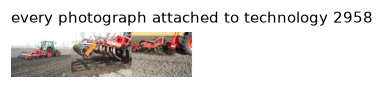

In [24]:
photo_count = photos.groupby("technology_id").size()
candidates  = visual[(photo_count.reindex(visual.index) >= 3)
                     & (photo_count.reindex(visual.index) <= 6)]
tech_id = int(candidates["machinery  (max)"].idxmax())
example = visual.loc[tech_id]

print(f"technology {tech_id}   -   {labels.loc[tech_id, 'country']}   "
      f"questionnaire says mechanisation = {labels.loc[tech_id, 'mechanisation']}")
print()
print(example.sort_values(ascending=False).round(2).to_string())

contact_sheet(photos[photos.technology_id == tech_id].image_id, cols=6, rows=1,
              title=f"every photograph attached to technology {tech_id}")

---
# Part 6 — Does any of this help the ecology?

This is the question WOCAT actually cares about, and the reason the earlier notebook existed. We
now approach it the long way round, through the chain we set up at the start:

<pre>
   image  ──►  visual concepts  ──►  16 named technology fields  ──►  biodiversity outcome
</pre>

The comparison is between **feature sets**, on identical rows and identical country-grouped folds.
We split the questionnaire deliberately in two, because the distinction matters more than anything
else in this Part:

| feature set | what it knows | fields |
|---|---|---|
| **site context** | *where the site is* | rainfall, slope, altitude, soil, landform, water |
| **practice** | *what was done there* | SLM group, measures, degradation addressed, purpose, land use |
| **visual evidence** | *what the photographs show* | the 16 fields we just built |

The targets are the biodiversity indicators from questionnaire section 6.1, each split at its
median into "improved a lot" versus "improved a little".

**Say this out loud before reading any number.** 92% of WOCAT records report an improvement, because
WOCAT documents practices that worked. "High" does not mean success and "low" does not mean failure
— low means *slightly better*. Everything here is a comparison of degree, and no causal claim is
available from this data at all.

In [25]:
from sklearn.impute import SimpleImputer

tech       = pd.read_csv(PROC / "technologies_biodiversity.csv")
m1         = pd.read_csv(PROC / "m1_features.csv").set_index("technology_id")
dictionary = pd.read_csv(PROC / "m1_feature_dictionary.csv")

SITE     = dictionary[dictionary.block == "environment"].column.tolist()
PRACTICE = dictionary[dictionary.block.isin(["technology", "degradation",
                                             "purpose", "landuse"])].column.tolist()

print(f"site context : {len(SITE)} features")
print(f"practice     : {len(PRACTICE)} features")
print(f"visual       : {visual.shape[1]} features")


def big_forest():
    return RandomForestClassifier(500, random_state=SEED, n_jobs=-1, min_samples_leaf=3)


def ecology(target, label):
    """Same rows, same folds, six feature sets."""
    base = tech[["technology_id", "country", target]].dropna()
    base = base[base.technology_id.isin(visual.index) & base.country.notna()].reset_index(drop=True)

    y = (base[target] > base[target].median()).astype(int).to_numpy()
    g = base.country.astype(str).to_numpy(dtype=object)
    if min(y.sum(), (1 - y).sum()) < 40:
        return None

    block = lambda cols: SimpleImputer(strategy="median").fit_transform(
        m1[cols].reindex(base.technology_id).to_numpy(dtype=float))
    X_site, X_practice = block(SITE), block(PRACTICE)
    X_visual = visual.reindex(base.technology_id).to_numpy()

    cv = list(StratifiedGroupKFold(5, shuffle=True, random_state=SEED).split(X_site, y, g))
    sets = {
        "site context":              X_site,
        "practice":                  X_practice,
        "site + practice":           np.hstack([X_site, X_practice]),
        "visual evidence":           X_visual,
        "site + visual":             np.hstack([X_site, X_visual]),
        "site + practice + visual":  np.hstack([X_site, X_practice, X_visual]),
    }
    out = {"outcome": label, "n": len(y), "high": int(y.sum())}
    for name, X in sets.items():
        out[name] = cross_val_score(big_forest(), X, y, cv=cv, scoring="roc_auc").mean()
    return out


ecology_rows = [
    ecology("bio_biomass_above_ground_C", "biomass / above-ground C"),
    ecology("biodiversity_score_mean",    "biodiversity score (mean)"),
    ecology("bio_plant_diversity",        "plant diversity"),
    ecology("bio_vegetation_cover",       "vegetation cover"),
    ecology("bio_habitat_diversity",      "habitat diversity"),
]
ecology_table = pd.DataFrame([r for r in ecology_rows if r]).set_index("outcome")
ecology_table.round(3)

site context : 69 features
practice     : 121 features
visual       : 16 features


,n,high,site context,practice,site + practice,visual evidence,site + visual,site + practice + visual
outcome,,,,,,,,
biomass / above-ground C,470,143,0.578,0.656,0.677,0.483,0.534,0.639
biodiversity score (mean),875,431,0.510,0.592,0.585,0.497,0.515,0.567
plant diversity,464,119,0.545,0.597,0.607,0.448,0.504,0.564
vegetation cover,347,85,0.442,0.583,0.553,0.541,0.504,0.566
habitat diversity,332,60,0.554,0.579,0.587,0.516,0.514,0.594


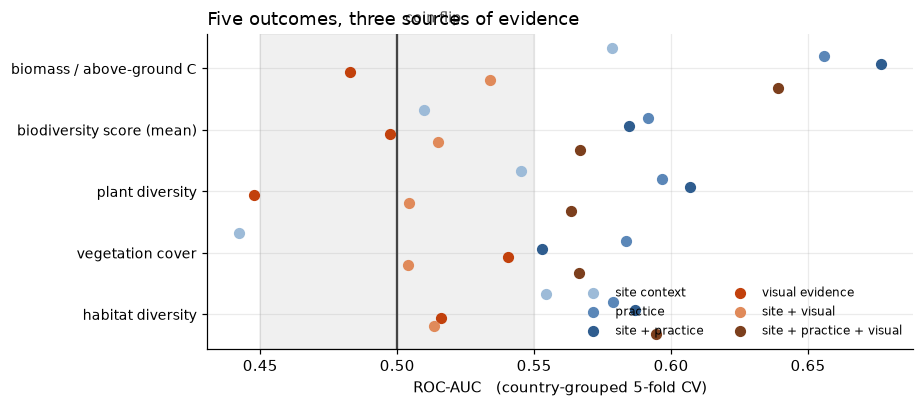

In [26]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))
sets = ["site context", "practice", "site + practice", "visual evidence",
        "site + visual", "site + practice + visual"]
palette = ["#9dbbd8", "#5b87b8", "#2f5d8f", "#c2410c", "#e08a5a", "#7c3f1d"]
y_pos = np.arange(len(ecology_table))
for i, (name, colour) in enumerate(zip(sets, palette)):
    ax.scatter(ecology_table[name], y_pos + (i - 2.5) * .13, s=40, color=colour,
               label=name, zorder=3)
ax.axvline(.5, color="#444", lw=1.5)
ax.axvspan(.45, .55, color="#888", alpha=.12)
ax.text(.5, -.75, "  coin flip", fontsize=9, color="#444")
ax.set_yticks(y_pos); ax.set_yticklabels(ecology_table.index, fontsize=9)
ax.set_xlabel("ROC-AUC   (country-grouped 5-fold CV)")
ax.invert_yaxis()
ax.legend(frameon=False, fontsize=8, ncol=2, loc="lower right")
ax.set_title("Five outcomes, three sources of evidence", loc="left")
plt.tight_layout(); plt.show()

### The answer is no, and this time we know what "no" means

**Visual evidence alone sits at chance** on every ecological outcome. **Adding it to the
questionnaire does not help**, and on the strongest target it very slightly hurts — which is what
adding noise to a random forest does.

The earlier notebook reached the same conclusion, and this version of it is worth much more, for
one reason. That null came from a 512-number black box, so it left an obvious escape route:
*"maybe a better image representation would work."* This null does not leave that route open.

Look at what we now know the image representation contains. It identifies terraces, machinery,
water infrastructure, livestock and trees well above chance (Part 3). It recovers thirteen of the
fourteen hand-made features (Part 4). It predicts a record's mechanisation, land use and SLM
measure from photographs alone (Part 5). **It is demonstrably a good description of the
intervention, and it still tells us nothing about the ecological outcome.**

That is no longer a missing result. It is a measurement:

> **The photographs describe what the practice *is*. They carry no usable signal about how well it
> *worked*.**

And on reflection it is the expected answer. A photograph is a single instant. The biodiversity
score is a compiler's judgement about a change over years, on a scale where 92% of the entries are
positive. Nothing in the frame can carry that.

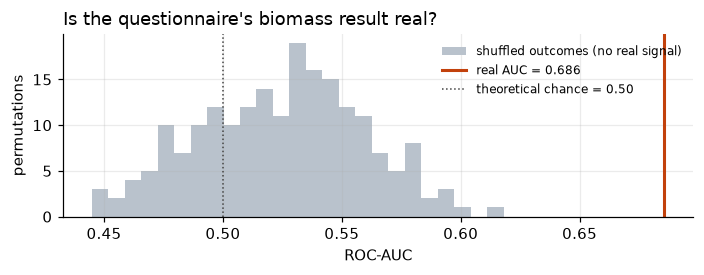

real AUC      : 0.686
shuffled mean : 0.525   <- not 0.50, see below
p-value       : 0.005


In [27]:
from sklearn.model_selection import permutation_test_score

best = tech[["technology_id", "country", "bio_biomass_above_ground_C"]].dropna()
best = best[best.country.notna()].reset_index(drop=True)
y_best = (best.bio_biomass_above_ground_C
          > best.bio_biomass_above_ground_C.median()).astype(int).to_numpy()
g_best = best.country.astype(str).to_numpy(dtype=object)
X_best = SimpleImputer(strategy="median").fit_transform(
    m1[SITE + PRACTICE].reindex(best.technology_id).to_numpy(dtype=float))
cv_best = list(StratifiedGroupKFold(5, shuffle=True, random_state=SEED)
               .split(X_best, y_best, g_best))

real, shuffled, p_value = permutation_test_score(
    big_forest(), X_best, y_best, groups=g_best, cv=cv_best, scoring="roc_auc",
    n_permutations=200, random_state=SEED, n_jobs=-1)

fig, ax = plt.subplots(figsize=(6.5, 2.6))
ax.hist(shuffled, bins=25, color="#b9c2cc", label="shuffled outcomes (no real signal)")
ax.axvline(real, color="#c2410c", lw=2, label=f"real AUC = {real:.3f}")
ax.axvline(.5, color="#444", lw=1, ls=":", label="theoretical chance = 0.50")
ax.set_xlabel("ROC-AUC"); ax.set_ylabel("permutations")
ax.set_title("Is the questionnaire's biomass result real?", loc="left")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

print(f"real AUC      : {real:.3f}")
print(f"shuffled mean : {shuffled.mean():.3f}   <- not 0.50, see below")
print(f"p-value       : {p_value:.3f}")

### Two things that chart tells us

**The questionnaire's biomass signal is real.** Shuffle the outcomes 200 times and the model never
gets near its actual score. This is the one genuinely useful predictive result available from this
database, and it comes entirely from the form.

**But look where the shuffled distribution is centred — above 0.50, not on it.** We shuffle the
outcomes *within each country*, so any tendency for records from a given region to be rated
generously survives the shuffle, and the model picks it up through correlated fields like altitude
and climate zone. A noticeable slice of the apparent lift over 0.5 is therefore not ecology at all:
it is **where the record came from and who filled in the form**.

Had we compared against the textbook 0.500 we would have reported a larger effect than exists. This
is exactly why you permute rather than assume.

---
# Part 7 — *Where* versus *what*, and a chart that misleads

Part 6 leaves one loose end, and it is the most interesting question in the notebook.

The biomass model works. But **what does it know?** The earlier notebook looked at the random
forest's feature-importance ranking, saw altitude, rainfall, soil depth and slope at the top, and
concluded:

> *"The model is mostly learning which kinds of place show large biomass gains, not which practices
> cause them."*

If that were true it would be a strong argument for this whole project: the questionnaire would be
describing **where**, the missing information would be **what was done**, and photographs are
exactly a record of what was done.

It is worth checking, because it is a claim drawn from a *ranking*, and rankings from random
forests are treacherous. Let us reproduce the chart first.

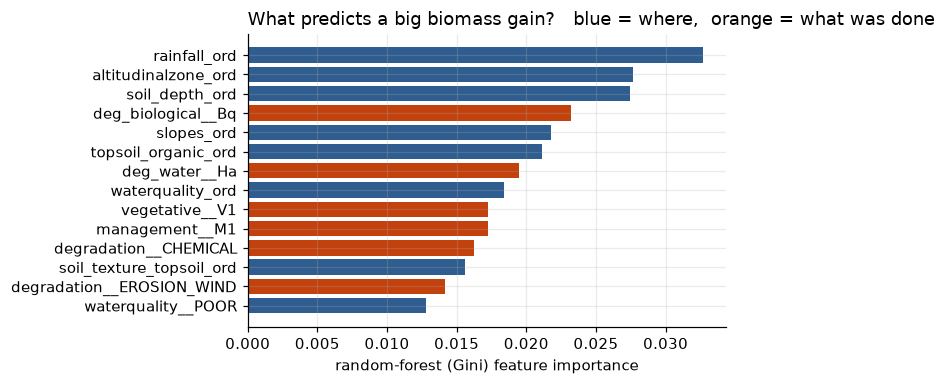

In [28]:
model = big_forest().fit(X_best, y_best)
importance = pd.Series(model.feature_importances_, index=SITE + PRACTICE).sort_values()

block_of = pd.Series({c: ("site context" if c in SITE else "practice") for c in SITE + PRACTICE})
top = importance.tail(14)

fig, ax = plt.subplots(figsize=(6.8, 3.6))
ax.barh(top.index, top.values,
        color=["#2f5d8f" if block_of[c] == "site context" else "#c2410c" for c in top.index])
ax.set_xlabel("random-forest (Gini) feature importance")
ax.set_title("What predicts a big biomass gain?   blue = where,  orange = what was done", loc="left")
plt.tight_layout(); plt.show()

### The ranking says "geography". The ablation says otherwise.

The top of that chart is dominated by site description, exactly as reported before. But a ranking
of individual features answers a different question from *"which block of the questionnaire carries
the signal?"* — and we can answer the second question directly, by simply training on one block at
a time. Those numbers are already in the Part 6 table; here they are on their own.

In [29]:
ablation = ecology_table.loc[["biomass / above-ground C"],
                             ["site context", "practice", "site + practice"]].T
ablation.columns = ["ROC-AUC"]
ablation["features"] = [len(SITE), len(PRACTICE), len(SITE) + len(PRACTICE)]

print("Gini importance mass, summed by block:")
print(importance.groupby(block_of).sum().round(3).to_string())
print()
ablation.round(3)

Gini importance mass, summed by block:
practice        0.515
site context    0.485



,ROC-AUC,features
site context,0.578,69
practice,0.656,121
site + practice,0.677,190


### Two corrections, and they run in opposite directions to the intuition

**First: the total importance mass is split roughly evenly between the two blocks.** The *top* of
the chart is site context, but the *mass* is not. A top-12 list is a poor summary of 190 features.

**Second, and decisively: trained on its own, the practice block beats the site block.** Knowing
*what was done* predicts the biomass outcome better than knowing *where it was done*, not worse.
The two together beat either, so both carry something — but the original reading was backwards.

### Why the chart lied

This is a well-known property of Gini importance and it is worth being able to name: **it is biased
towards features with more distinct values.** A feature with five levels offers a tree more places
to split than a 0/1 flag, so it accumulates importance even when it is no more informative.

The site block is full of ordinal variables — rainfall class, altitude band, slope class. The
practice block is almost entirely binary flags. So the site features rise to the top of the ranking
for a reason that has nothing to do with predicting biomass.

mean number of distinct values per feature:
practice        2.00
site context    2.83

correlation(Gini importance, number of distinct values) = 0.64


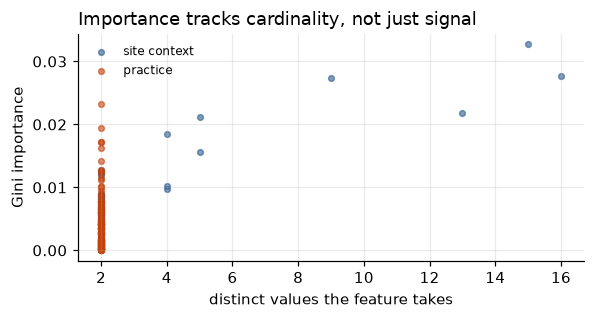

In [30]:
cardinality = pd.Series({c: m1[c].nunique() for c in SITE + PRACTICE})

print("mean number of distinct values per feature:")
print(cardinality.groupby(block_of).mean().round(2).to_string())
print(f"\ncorrelation(Gini importance, number of distinct values) = "
      f"{np.corrcoef(importance.reindex(cardinality.index), cardinality)[0, 1]:.2f}")

fig, ax = plt.subplots(figsize=(5.6, 3))
for name, colour in [("site context", "#2f5d8f"), ("practice", "#c2410c")]:
    m = (block_of == name).reindex(cardinality.index)
    ax.scatter(cardinality[m], importance.reindex(cardinality.index)[m], s=14,
               alpha=.6, color=colour, label=name)
ax.set_xlabel("distinct values the feature takes")
ax.set_ylabel("Gini importance")
ax.set_title("Importance tracks cardinality, not just signal", loc="left")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

### What that means for this project

The hoped-for gap is not there. The questionnaire is **not** mainly describing *where*; its
description of *what was done* is the stronger half of it. So the opening for photographs is
narrower than the premise assumed — they would have to add something beyond an already-good written
description of the practice, and Part 6 shows they do not.

This is worth reporting as a finding in its own right, because it is a correction of a published
reading of the same data, obtained with three lines of code. **When a claim rests on a feature
ranking, re-derive it with an ablation before believing it.**

---
# Part 8 — Where the photographs actually pay: filling in the form

Parts 6 and 7 close off the ecological route. But Part 5 established something practical that has
nothing to do with ecology:

> A model that sees only photographs can tell, well above chance, whether a technology is
> mechanised — **without reading the questionnaire.**

That is worth something to WOCAT, because **the questionnaire has holes**. Fields get left blank.
And unlike a biodiversity outcome, a blank `mechanisation` field is a fact that already exists in
the world and is sitting in the photographs.

So the application is not prediction, it is **assisted completion**: go through the records where
the field is empty, and hand a human a short, ranked list to check.

First, how well can we do it, scored honestly on records where we *do* know the answer?

In [31]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

tech_ids, X_tech = representations["mean + max"]
mech   = labels.mechanisation.reindex(tech_ids)
countr = labels.country.reindex(tech_ids)

known = mech.isin(["MANUAL", "MECHANISED"]).to_numpy() & countr.notna().to_numpy()
blank = mech.isna().to_numpy()

y_mech  = (mech[known] == "MECHANISED").astype(int).to_numpy()
g_mech  = countr[known].astype(str).to_numpy(dtype=object)
cv_mech = list(StratifiedGroupKFold(5, shuffle=True, random_state=SEED)
               .split(X_tech[known], y_mech, g_mech))

p_mech = cross_val_predict(logreg(), X_tech[known], y_mech, cv=cv_mech,
                           method="predict_proba")[:, 1]

print(f"records with photographs      : {len(tech_ids):,}")
print(f"  field says MANUAL/MECHANISED: {known.sum():,}   ({y_mech.mean():.1%} mechanised)")
print(f"  field left blank            : {blank.sum():,}   <- what we would help with")
print(f"\nheld-out AUC (country-grouped): {roc_auc_score(y_mech, p_mech):.3f}")

thresholds = pd.DataFrame([
    {"confidence": f"p >= {t:.2f}",
     "records flagged": int((p_mech >= t).sum()),
     "precision": precision_score(y_mech, p_mech >= t, zero_division=0),
     "recall": recall_score(y_mech, p_mech >= t)}
    for t in (.5, .6, .7, .8, .9)]).set_index("confidence")
thresholds["lift over base rate"] = thresholds.precision / y_mech.mean()
thresholds.round(2)

records with photographs      : 1,450
  field says MANUAL/MECHANISED: 1,120   (25.6% mechanised)
  field left blank            : 258   <- what we would help with

held-out AUC (country-grouped): 0.781


,records flagged,precision,recall,lift over base rate
confidence,,,,
p >= 0.50,339,0.54,0.64,2.12
p >= 0.60,203,0.70,0.50,2.75
p >= 0.70,128,0.80,0.36,3.11
p >= 0.80,71,0.89,0.22,3.46
p >= 0.90,39,0.97,0.13,3.80


### Read that table the way a WOCAT editor would

The number that matters is **precision at high confidence versus the base rate**. Guessing blindly,
one record in four is mechanised. Working down the model's most confident flags, the hit rate is
several times that — and at the top of the list it is very high indeed, on a small number of
records.

That trade is the whole design. Recall falls away as confidence rises, and **that is fine**,
because the job is not to find every mechanised record. The job is to **put the right records at
the top of a reviewer's queue**. A tool that hands an editor forty records and is right about
almost all of them is useful; a tool that hands them four hundred and is right about half is not.

Framed that way it is defensible:

- ✅ *"These records have no mechanisation entry and their photographs look mechanised. Please check
  them first."*
- ❌ *"Set `mechanisation = MECHANISED` on these records."*

Now run it on the records where the field is genuinely empty.

258 records have no mechanisation entry.  Ranked by the photographs:
  most confident : p = 0.79
  median         : p = 0.43
  least          : p = 0.22

  above 0.60:  15 records   <- the review queue
  below 0.10:   0 records   <- none look confidently manual

top of the queue:
 technology_id  p_mechanised
           987         0.785
          1727         0.780
          1662         0.763
          1615         0.721
          1668         0.696
          7274         0.675
          1704         0.660
          1010         0.659


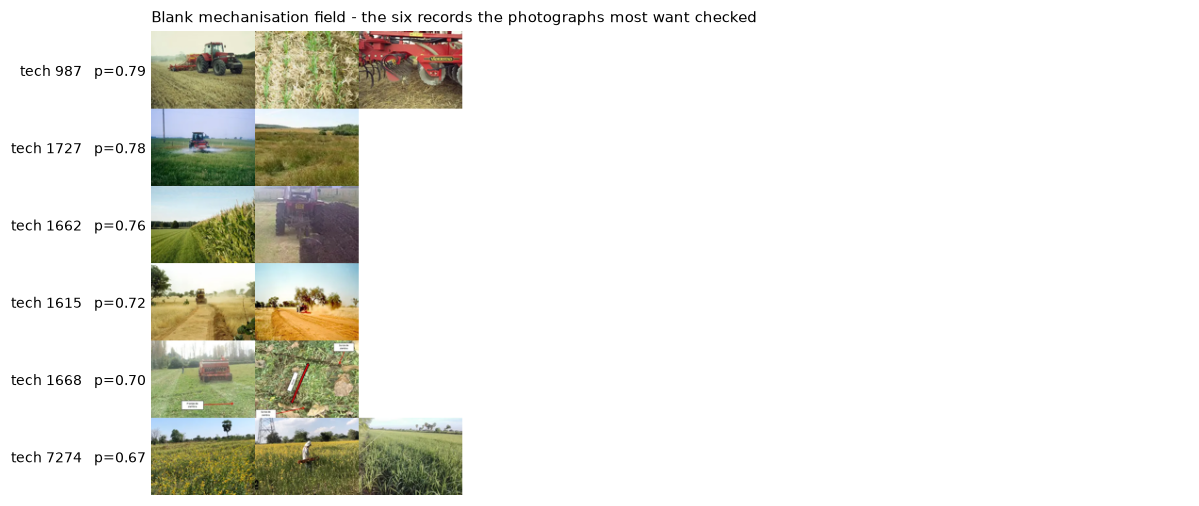

In [32]:
fitted  = logreg().fit(X_tech[known], y_mech)
p_blank = fitted.predict_proba(X_tech[blank])[:, 1]

queue = pd.DataFrame({"technology_id": tech_ids[blank], "p_mechanised": p_blank}) \
          .sort_values("p_mechanised", ascending=False).reset_index(drop=True)

print(f"{blank.sum()} records have no mechanisation entry.  Ranked by the photographs:")
print(f"  most confident : p = {queue.p_mechanised.iloc[0]:.2f}")
print(f"  median         : p = {queue.p_mechanised.median():.2f}")
print(f"  least          : p = {queue.p_mechanised.iloc[-1]:.2f}")
print(f"\n  above 0.60: {(p_blank >= .6).sum():>3} records   <- the review queue")
print(f"  below 0.10: {(p_blank <= .1).sum():>3} records   <- none look confidently manual")
print("\ntop of the queue:")
print(queue.head(8).round(3).to_string(index=False))

rows_sheet({f"tech {int(r.technology_id)}   p={r.p_mechanised:.2f}":
            photos[photos.technology_id == r.technology_id].image_id.head(10)
            for r in queue.head(6).itertuples()},
           title="Blank mechanisation field - the six records the photographs most want checked")

### Look at the sheet, not the numbers

This is the moment to check the whole notebook by eye. If those rows contain tractors, ploughs and
machinery, the chain we built — pixels → concepts → technology fields → a reviewer's queue — does
what it claims. If they do not, no AUC anywhere above would rescue it.

Two honest caveats belong next to this sheet.

**The ranking is over the records where the field is blank, not over confident detections.** The
top of this queue sits lower than the top of the scored table above, because these are the records
the compiler left blank — and a record with no mechanisation entry is more likely to be one where
mechanisation was not the point. A queue is still the right output; a threshold would not be.

**And a blank field is not a random blank.** If compilers skip the field precisely when the answer
is "none of these", then the records we are ranking are systematically unlike the records we
trained on. Nothing here detects that, and a real deployment would need to check it.

Even so, this is the shape of the honest deliverable for WOCAT. Not *"AI predicts biodiversity"*,
which Part 6 rules out. Something smaller and real: **a second, automatic reading of evidence the
database is already storing, used to point a human at the records worth checking.**

---
# Part 9 — What we found, and what we may not claim

### The findings, strongest first

1. **The archive has a visual taxonomy, and it was never recorded.** Eight kinds of photograph —
   water & built structures, machinery, people in the field, diagrams & charts, trees & orchards,
   open/dry terrain, dense crops & foliage, people & equipment — found with no labels at all, and
   confirmed against a questionnaire field the clustering never saw. *(M1, unsupervised)*
2. **Photographs identify what a technology is.** From pictures alone, well above baseline, a model
   recovers a record's mechanisation, land use and SLM measure, and detects terraces, machinery,
   water infrastructure, livestock and trees at ROC-AUC 0.70–0.82. *(M1 + M2, supervised)*
3. **Photographs say nothing about how well it worked.** Visual evidence sits at chance on every
   biodiversity outcome and adds nothing to the questionnaire. This time the image representation
   is one whose contents we have *measured* — which closes the "maybe a better representation would
   work" escape route the earlier 512-number black box left open.
4. **Choosing the regularisation strength was worth more than training the network.** Selecting `C`
   by inner cross-validation moved the frozen CNN's average AUC by more than ten points, in
   thirteen seconds. Fine-tuning the last block for seven minutes **lost** to it on all three
   concepts tried. *(M2 — with the caveat that only the frozen model's hyper-parameter was tuned)*
5. **Learned features contain hand-made features.** The embedding reconstructs thirteen of our
   fourteen features. The fourteenth, `aspect`, it cannot reconstruct at all — because
   `Resize((224, 224))` destroys it before the first convolution. Adding it back changes nothing:
   the model could not see it *and* did not need it. Two different facts, and only an experiment
   separates them.
6. **Using all 4,395 photographs beats the header photo**, clearly for mechanisation and
   consistently elsewhere. `max` pooling suits presence questions, `mean` suits site questions.
7. **A feature-importance chart misled a previous reading of this data.** Ranked individually the
   site-context features dominate; trained as blocks, the practice block predicts biomass *better*
   than the site block. Gini importance tracks how many distinct values a feature has.
8. **The usable application is data completion, not prediction.** Mechanisation from photographs
   alone reaches AUC ≈ 0.78 at record level, with several times the base-rate precision at high
   confidence — enough to rank a reviewer's queue over the records where the field is blank.

### What we must *not* say

- ❌ *"Photographs are useless."* They describe the practice well. They just do not score it.
- ❌ *"This technology causes biodiversity gains."* Every record is a success story; 92% report
  improvement. There is no failure group to contrast against, so no causal claim is available.
- ❌ *"The model is 78% accurate."* AUC is not accuracy. Say: *"shown one mechanised record and one
  manual record, it ranks them correctly 78% of the time."*
- ❌ *"The photo reveals the land use."* Every score here predicts **what the compiler wrote on the
  form**. If compilers systematically photograph what they wrote down, the model has learned their
  habits rather than the landscape. The distinction is the difference between a careful study and
  an overclaiming one.
- ❌ *"Fine-tuning does not help."* Our fine-tune lost to a tuned frozen model, with fixed
  hyper-parameters and 3 epochs. That is evidence about *this* comparison, not about fine-tuning.
- ❌ *"More data would fix the ecological null."* Nothing in five outcomes and three representations
  points that way. Cleaner **labels** are the constraint, not more rows.

### If we had more time, in order of value

1. **Hand-label 300 photographs** with the eight visual concepts. Part 2 showed caption keywords
   have high precision and poor recall, and Part 3 showed the ceiling is the labels. This is the
   single highest-value day of work available.
2. **Give the fine-tune the same courtesy as the baseline** — a real hyper-parameter search over
   learning rate, epochs and how much to unfreeze. Finding 4 is a fair result but not a fair fight.
3. **Try CLIP zero-shot.** It scores an image against text prompts, so you can ask directly for
   *"a photograph of a tractor"* with no labelling at all — a cheap comparison against both our
   k-means clusters and our caption keywords.
4. **Attention-weighted aggregation.** We used mean and max over a record's photographs. Letting
   the model learn which photograph to listen to is the natural next step, and Part 5 shows the
   header photo is not always it.
5. **Use the captions as text**, not just as keyword labels. 1.2M words of description sit beside
   the images and were used here only to grep for eight patterns.
6. **The technical drawings are a separate, untouched modality** — visually consistent, unlike the
   photographs, and present on most records.

### A 15-minute running order

| min | slide | the one sentence to say |
|---|---|---|
| 0–2 | The pivot | "Asking a photograph to predict a five-year ecological outcome failed — and should have. So we asked it what it can actually see." |
| 2–4 | The archive | "4,396 photographs, all of them this time. Nobody had ever looked at two thirds of them." |
| 4–7 | **The two cluster sheets** | "Same algorithm, same k, same photos. Hand-made features found colour. The network found tractors." |
| 7–8 | The silhouette trap | "The metric said 'no structure'. The pictures say eight groups. It was answering a different question." |
| 8–10 | **M1 → frozen → fine-tuned** | "The biggest win in the whole notebook was choosing a regularisation strength. It beat seven minutes of GPU training." |
| 10–11 | The `aspect` probe | "The network reproduces thirteen of our fourteen features. The one it cannot is the one our own preprocessing threw away — and adding it back changes nothing." |
| 11–13 | **The ecology chart** | "Visual evidence is at chance on every outcome. We now know exactly what that representation contains, so this null means something." |
| 13–15 | **The review queue** | "Where the photographs pay is filling in the form: several times the base rate, pointed at 258 blank fields." |

**Four figures carry the talk** — the two cluster sheets, the three-way M1/M2 comparison, the
ecology chart, and the flagged-records sheet. Everything else is narration.